In [1]:
import sys, os; sys.path.insert(0, os.path.join("..", "src")) if os.path.basename(os.getcwd())=="notebooks" else sys.path.insert(0, "src")
import config, data_layer, econometrics as ek, validate, outputs

# FR11 — Ticarət-tədiyə strukturu

Ticarət və tədiyə balansına görə idxal-ixracın əsas göstəriciləri, struktur təhlili və
proqnozlaşdırılması (MİİS §15.5.1, bənd 2.4.1.13.-14.; hüquqi əsas — Nazirlər Kabinetinin
24.05.2004 tarixli 75 nömrəli qərarı, bənd 2.4.1).

## 1. Tələb

**Spesifikasiyanın mətni (§15.5.1, FR11):** "Ticarət və tədiyə balansına görə idxal-ixracın əsas
göstəriciləri, struktur təhlili və proqnozlaşdırılması."

Bu tələb FR7-nin hesabladığı axınları (malların və xidmətlərin ixracı-idxalı, neft-qaz və qeyri-neft
kəsimində) bir addım irəli aparır: xam rəqəmlərdən struktur mənzərəyə keçir. Üç iş görülür.
Birincisi, **tərkib balansları** — neft-qaz ticarət balansı və qeyri-neft ticarət balansı — ayrıca
hesablanır, çünki onların davranışı tamamilə fərqlidir: biri dünya neft qiymətinin, digəri daxili
tələbin funksiyasıdır. İkincisi, **qeyri-neft örtmə əmsalı** (qeyri-neft ixracının qeyri-neft
idxalını neçə faiz örtdüyü) və **ixracın diversifikasiyası** (məhsul, ölkə və ixracatçı kəsimində)
təhlil olunur — bunlar Ticarət vərəqinin öz diversifikasiya sətirlərindən (19–31) gəlir. Üçüncüsü,
tədiyə balansının **ilkin və təkrar gəlirlər** maddələri qiymətləndirilir və FR12-yə ötürülür, çünki
bu iki maddə olmadan FR7-nin ticarət və xidmət balansları cari hesaba tamamlana bilmir.

İcra ardıcıllığında (BUILD_CONTEXT §D2) bu dəftər FR7-dən sonra yerləşir və onun nəşr etdiyi
`outputs/forecast_long.csv` sətirlərini (neft-qaz və qeyri-neft ixrac-idxal yolları, mərkəzi yol və
yelpik zolağı ilə birgə) birbaşa giriş olaraq istifadə edir — yeni ekonometrik model qurmur, mövcud
yolların üzərində struktur dekompozisiya aparır. Tək istisna ilkin gəlirlər tənliyidir: bu, öz
qiymətləndirməsini tələb edən yeganə davranış tənliyidir. Dəftərin yazdığı ilkin/təkrar gəlir yolları
FR12-nin (tədiyə balansının konsolidasiyası) girişidir.

## 2. Məlumat

Bu dəftər iki fərqli mənbədən qidalanır.

**FR7-nin nəşr etdiyi yollar** (`outputs/forecast_long.csv`, `fr = "FR7"`) — malların ixracı-idxalı
neft-qaz və qeyri-neft kəsimində, faktiki (2010–2025) və proqnoz (2026–2030, mərkəzi yol + yelpik
zolağı) hissələri ilə birlikdə. Bunlar `data_layer.actuals(...)`-dan deyil, birbaşa nəşr olunmuş
fayldan oxunur, çünki proqnoz hissəsi (2026–2030) yalnız orada mövcuddur; faktiki hissə isə FR7-nin
öz `data_layer.actuals(...)` çağırışı ilə eynidir (Bölmə 8-də bu bərabərlik ayrıca yoxlanılır).

| `series_code` | Təsvir | Əhatə |
|---|---|---|
| `exp_goods_oil` / `imp_goods_oil` | Neft-qaz malların ixracı/idxalı | 2010–2030 |
| `exp_goods_nonoil` / `imp_goods_nonoil` | Qeyri-neft malların ixracı/idxalı | 2010–2030 |
| `trade_balance` | Xarici ticarət balansı (məcmu) | 2010–2030 |

**`data_layer.actuals(...)` vasitəsilə oxunan faktiki sıralar** (2010–2025, n = 16):

| `series_code` | Təsvir | Vahid | Vərəq, sətir |
|---|---|---|---|
| `primary_income` | İlkin gəlirlər, xalis | mln USD | Tədiyyə Balansı, 56 |
| `secondary_income` | Təkrar gəlirlər, xalis | mln USD | Tədiyyə Balansı, 78 |
| `services_balance` | Xidmətlər balansı | mln USD | Tədiyyə Balansı, 13 |
| `current_account` | Cari əməliyyatlar hesabı | mln USD | Tədiyyə Balansı, 3 |

**Diversifikasiya sıraları** (əsas iş kitabının **Ticarət** vərəqi, sətir 19–31; `data_layer.wb_annual(...)`
ilə oxunur, çünki bu sətirlər kataloq spesifikasiyasında yoxdur və ona görə `actuals()`-un D1
mühafizəsindən kənardadır — proqnoz ilinin faktiki obyektə düşməməsi bu dəftərdə **əl ilə**,
`year <= config.LAST_ACTUAL` şərti ilə tətbiq olunur): ixrac olunan məhsul çeşidlərinin sayı,
top-10/20/30 məhsulun ixracda payı, ixrac olunan ölkələrin sayı, top-2/5/10/15 ölkənin payı, kənd
təsərrüfatı ixracında Rusiyanın payı, top-10/20/30 ixracatçının payı. Əhatə 2018–2025 (məhsul sayı,
n = 8) və 2021–2025 (qalan bütün nisbətlər, n = 5) — bu, Bölmə 2.2-də açıq qeyd olunan qısa nümunə
məhdudiyyətidir.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import Math, display

pd.set_option("display.width", 220)
LA, FY = config.LAST_ACTUAL, list(config.FY)          # 2025 və 2026–2030
H = len(FY)

# --- FR7-nin nəşr etdiyi yollar: faktiki + proqnoz, mərkəzi + yelpik zolağı ------------------
FL = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))
fr7 = FL[FL["fr"] == "FR7"]


def fr7_series(code_, source="ours", kind=None):
    d = fr7[(fr7["series_code"] == code_) & (fr7["source"] == source)]
    if kind:
        d = d[d["kind"] == kind]
    return d.set_index("year").sort_index()


TRADE_CODES = ["exp_goods_oil", "imp_goods_oil", "exp_goods_nonoil", "imp_goods_nonoil"]
HIST = {c: fr7_series(c, "ours", "actual")["value"] for c in TRADE_CODES}
FC = {c: fr7_series(c, "ours", "forecast")["value"] for c in TRADE_CODES}
BAND = {c: fr7_series(c, "ours", "forecast")[["lo80", "hi80", "lo50", "hi50"]] for c in TRADE_CODES}
MB = {c: fr7_series(c, "template_sample", "forecast")["value"] for c in TRADE_CODES}
FULL = {c: pd.concat([HIST[c], FC[c]]).sort_index() for c in TRADE_CODES}

TB_full = pd.concat([fr7_series("trade_balance", "ours", "actual")["value"],
                     fr7_series("trade_balance", "ours", "forecast")["value"]]).sort_index()

PI = data_layer.actuals("primary_income")
SI = data_layer.actuals("secondary_income")
SB = data_layer.actuals("services_balance")
CA = data_layer.actuals("current_account")

print("FR7-dən oxunan yolların əhatəsi:")
for c in TRADE_CODES:
    print(f"  {c:<18} faktiki {HIST[c].index.min()}-{HIST[c].index.max()} "
          f"({len(HIST[c])} il), proqnoz {FC[c].index.min()}-{FC[c].index.max()}")

# faktiki hissənin FR7-nin öz mənbəyi (data_layer.actuals) ilə eyni olduğunu təsdiqləyir
for c in TRADE_CODES:
    assert (HIST[c] - data_layer.actuals(c)).abs().max() < 1e-9, f"{c}: FR7 faktiki sırası uyğun gəlmir"
print("\nfaktiki hissə data_layer.actuals(...) ilə dəqiq üst-üstə düşür.")

FR7-dən oxunan yolların əhatəsi:
  exp_goods_oil      faktiki 2010-2025 (16 il), proqnoz 2026-2030
  imp_goods_oil      faktiki 2010-2025 (16 il), proqnoz 2026-2030
  exp_goods_nonoil   faktiki 2010-2025 (16 il), proqnoz 2026-2030
  imp_goods_nonoil   faktiki 2010-2025 (16 il), proqnoz 2026-2030

faktiki hissə data_layer.actuals(...) ilə dəqiq üst-üstə düşür.


### 2.1. "Neft profisiti qeyri-neft kəsirini maliyyələşdirir" — hesab

Aşağıdakı kod xanası ticarətin tərkib balanslarını və bu balansların ödəniş balansına necə
tamamlandığını 2025-ci ilin faktiki rəqəmləri üzərində göstərir.

In [3]:
oil_tb_2025 = float(FULL["exp_goods_oil"].loc[LA] - FULL["imp_goods_oil"].loc[LA])
nonoil_tb_2025 = float(FULL["exp_goods_nonoil"].loc[LA] - FULL["imp_goods_nonoil"].loc[LA])
tb_2025 = float(TB_full.loc[LA])
sb_2025 = float(SB.loc[LA])
pi_2025 = float(PI.loc[LA])
si_2025 = float(SI.loc[LA])
ca_2025 = float(CA.loc[LA])

print(f"neft-qaz ticarət balansı, {LA}:      {oil_tb_2025:+10.1f} mln USD  "
      f"(ixrac {FULL['exp_goods_oil'].loc[LA]:.1f}, idxal {FULL['imp_goods_oil'].loc[LA]:.1f})")
print(f"qeyri-neft ticarət balansı, {LA}:     {nonoil_tb_2025:+10.1f} mln USD  "
      f"(ixrac {FULL['exp_goods_nonoil'].loc[LA]:.1f}, idxal {FULL['imp_goods_nonoil'].loc[LA]:.1f})")
print(f"  = məcmu ticarət balansı, {LA}:      {oil_tb_2025 + nonoil_tb_2025:+10.1f} mln USD  "
      f"(FR7-nin nəşr etdiyi rəqəm: {tb_2025:+.1f})")
print(f"xidmətlər balansı, {LA}:              {sb_2025:+10.1f} mln USD")
print(f"  = mal + xidmət balansı, {LA}:       {tb_2025 + sb_2025:+10.1f} mln USD")
print(f"ilkin gəlirlər, xalis, {LA}:          {pi_2025:+10.1f} mln USD")
print(f"təkrar gəlirlər, xalis, {LA}:         {si_2025:+10.1f} mln USD")
print(f"  = cari hesab, {LA}:                 {tb_2025 + sb_2025 + pi_2025 + si_2025:+10.1f} mln USD  "
      f"(nəşr olunan rəqəm: {ca_2025:+.1f})")
print(f"\nneft profisitinin qeyri-neft kəsirini örtmə nisbəti: "
      f"{abs(nonoil_tb_2025) / oil_tb_2025 * 100:.1f} % (kəsirin qalan hissəsi profisit kimi qalır)")

neft-qaz ticarət balansı, 2025:        +18078.7 mln USD  (ixrac 20605.1, idxal 2526.4)
qeyri-neft ticarət balansı, 2025:       -11700.2 mln USD  (ixrac 3469.5, idxal 15169.7)
  = məcmu ticarət balansı, 2025:         +6378.6 mln USD  (FR7-nin nəşr etdiyi rəqəm: +6378.6)
xidmətlər balansı, 2025:                 -1659.2 mln USD
  = mal + xidmət balansı, 2025:          +4719.4 mln USD
ilkin gəlirlər, xalis, 2025:             -1986.5 mln USD
təkrar gəlirlər, xalis, 2025:             +742.1 mln USD
  = cari hesab, 2025:                    +3475.1 mln USD  (nəşr olunan rəqəm: +3475.1)

neft profisitinin qeyri-neft kəsirini örtmə nisbəti: 64.7 % (kəsirin qalan hissəsi profisit kimi qalır)


2025-ci ilin rəqəmləri bu accounting-i bir cümlədə göstərir: neft-qaz ticarət balansı yuxarıdakı
xanada göründüyü kimi böyük profisitdədir, qeyri-neft ticarət balansı isə kəsirdədir və bu kəsirin
təxminən üçdə ikisi (65 %) neft profisiti tərəfindən maliyyələşdirilir, qalan üçdə bir hissə məcmu
ticarət balansının özündə profisit kimi qalır. Xidmətlər balansının əlavə kəsiri və ilkin/təkrar gəlirlərin
xalis təsiri əlavə olunduqda əldə edilən cəm nəşr olunan cari hesab rəqəmi ilə dəqiq üst-üstə düşür
— bu, Bölmə 8-də müstəqil olaraq yenidən yoxlanılır. Proqnoz üfüqündə eyni struktur davam edir:
neft-qaz balansı yüksək səviyyədə qalır, qeyri-neft kəsiri isə daxili absorbsiyanın artması ilə
dərinləşir (Bölmə 7).

In [4]:
# --- tərkib balansları və örtmə əmsalı: FR7-nin sürücülərinin fərqi/nisbəti, YENİ reqressiya yoxdur
oil_tb = FULL["exp_goods_oil"] - FULL["imp_goods_oil"]
nonoil_tb = FULL["exp_goods_nonoil"] - FULL["imp_goods_nonoil"]
nonoil_cov = FULL["exp_goods_nonoil"] / FULL["imp_goods_nonoil"] * 100.0


def _diff_band(xcode, mcode):
    # Balansın yelpik zolağı: FR07 Bölmə 8-in konvensiyası — ixracın aşağı sərhədi ilə idxalın
    # YUXARI sərhədinin fərqi. Dəqiq ifadə: bu, komponent xətalarının bir-birini ƏKS istiqamətdə
    # gücləndirdiyi (balans üçün ən pis) hal üçün qurulur, ona görə maksimal dərəcədə
    # konservativdir. Xətalar praktikada eyni istiqamətdə hərəkət etsə (hər ikisi neft
    # qiymətindən asılıdır), həqiqi zolaq bundan DAR olacaq.
    bx, bm = BAND[xcode], BAND[mcode]
    return pd.DataFrame({"lo80": bx["lo80"] - bm["hi80"], "hi80": bx["hi80"] - bm["lo80"],
                         "lo50": bx["lo50"] - bm["hi50"], "hi50": bx["hi50"] - bm["lo50"]})


def _ratio_band(xcode, mcode, central):
    # Örtmə əmsalının zolağı: NİSBİ yarım-enlərin CƏMİ. Bu, delta üsulunun müstəqillik
    # halı (kvadratların cəminin kökü) DEYİL — cəm forması iki xətanın tam əks istiqamətdə
    # hərəkət etdiyi halı təmsil edir və yuxarıdakı fərq zolağı ilə eyni konservativ məntiqi
    # saxlayır. Uzun üfüqdə bu, aşağı sərhədi sıfıra yaxınlaşdıra bilər (Bölmə 9).
    bx, bm = BAND[xcode], BAND[mcode]
    cx, cm = FC[xcode], FC[mcode]
    rel80 = (bx["hi80"] - bx["lo80"]) / 2 / cx + (bm["hi80"] - bm["lo80"]) / 2 / cm
    rel50 = (bx["hi50"] - bx["lo50"]) / 2 / cx + (bm["hi50"] - bm["lo50"]) / 2 / cm
    c = central.loc[FY]
    return pd.DataFrame({"lo80": c * (1 - rel80), "hi80": c * (1 + rel80),
                         "lo50": c * (1 - rel50), "hi50": c * (1 + rel50)})


oil_tb_band = _diff_band("exp_goods_oil", "imp_goods_oil")
nonoil_tb_band = _diff_band("exp_goods_nonoil", "imp_goods_nonoil")
nonoil_cov_band = _ratio_band("exp_goods_nonoil", "imp_goods_nonoil", nonoil_cov)

print("Neft-qaz ticarət balansı, mln USD:")
print(pd.concat([oil_tb.loc[FY].rename("mərkəzi"), oil_tb_band], axis=1).round(1))
print("\nQeyri-neft ticarət balansı, mln USD:")
print(pd.concat([nonoil_tb.loc[FY].rename("mərkəzi"), nonoil_tb_band], axis=1).round(1))
print("\nQeyri-neft örtmə əmsalı, %:")
print(pd.concat([nonoil_cov.loc[FY].rename("mərkəzi"), nonoil_cov_band], axis=1).round(1))

Neft-qaz ticarət balansı, mln USD:
      mərkəzi     lo80     hi80     lo50     hi50
year                                             
2026  17527.9  12692.7  22943.3  14928.1  20308.2
2027  17327.4  10526.0  25102.2  13660.4  21192.0
2028  17159.8   9124.1  26938.7  12727.8  21934.5
2029  18029.5   8529.6  29902.5  12856.8  23907.2
2030  18025.2   7450.1  31805.8  12356.1  24603.8

Qeyri-neft ticarət balansı, mln USD:
      mərkəzi     lo80    hi80     lo50     hi50
year                                            
2026 -12466.1 -16206.7 -9132.4 -14372.0 -10621.0
2027 -13340.8 -19498.7 -8278.1 -16452.0 -10596.6
2028 -14285.0 -22912.1 -7547.7 -18594.6 -10598.6
2029 -15309.6 -26581.9 -6894.1 -20859.8 -10651.8
2030 -16421.3 -30695.8 -6161.8 -23232.2 -10799.0

Qeyri-neft örtmə əmsalı, %:
      mərkəzi  lo80  hi80  lo50  hi50
year                                 
2026     22.8  14.6  31.0  18.5  27.1
2027     22.6  10.7  34.6  16.5  28.8
2028     22.5   7.5  37.5  14.7  30.4
2029     22.4  

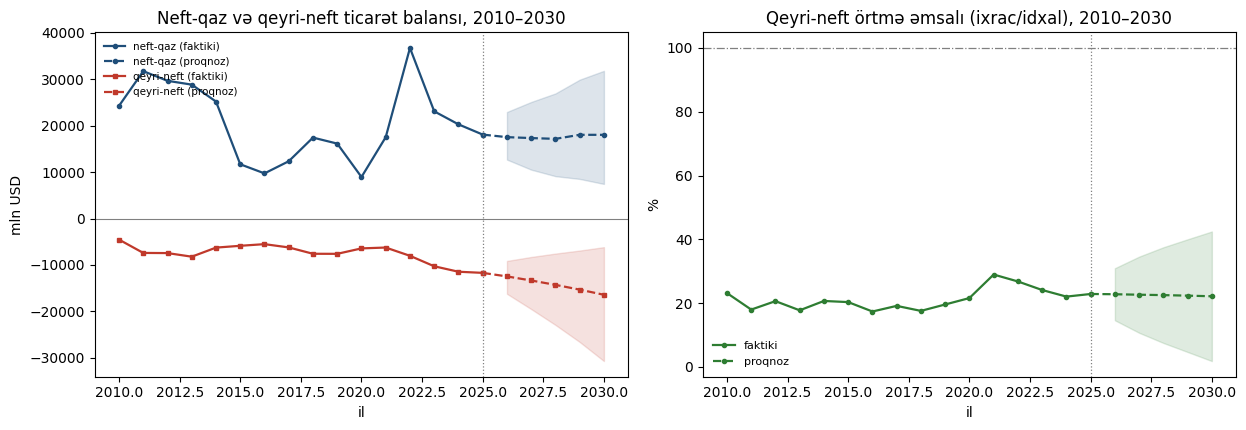

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))
ax = axes[0]
ax.plot(oil_tb.loc[:LA].index, oil_tb.loc[:LA], "-o", ms=3, lw=1.6, color="#1f4e79", label="neft-qaz (faktiki)")
ax.plot(oil_tb.loc[LA:].index, oil_tb.loc[LA:], "--o", ms=3, lw=1.6, color="#1f4e79", label="neft-qaz (proqnoz)")
ax.fill_between(oil_tb_band.index, oil_tb_band["lo80"], oil_tb_band["hi80"], color="#1f4e79", alpha=0.15)
ax.plot(nonoil_tb.loc[:LA].index, nonoil_tb.loc[:LA], "-s", ms=3, lw=1.6, color="#c0392b", label="qeyri-neft (faktiki)")
ax.plot(nonoil_tb.loc[LA:].index, nonoil_tb.loc[LA:], "--s", ms=3, lw=1.6, color="#c0392b", label="qeyri-neft (proqnoz)")
ax.fill_between(nonoil_tb_band.index, nonoil_tb_band["lo80"], nonoil_tb_band["hi80"], color="#c0392b", alpha=0.15)
ax.axhline(0, color="grey", lw=0.8)
ax.axvline(LA, color="grey", ls=":", lw=0.9)
ax.set_title("Neft-qaz və qeyri-neft ticarət balansı, 2010–2030")
ax.set_ylabel("mln USD"); ax.set_xlabel("il")
ax.legend(frameon=False, fontsize=7.5, loc="upper left")

ax = axes[1]
ax.plot(nonoil_cov.loc[:LA].index, nonoil_cov.loc[:LA], "-o", ms=3, lw=1.6, color="#2e7d32", label="faktiki")
ax.plot(nonoil_cov.loc[LA:].index, nonoil_cov.loc[LA:], "--o", ms=3, lw=1.6, color="#2e7d32", label="proqnoz")
ax.fill_between(nonoil_cov_band.index, nonoil_cov_band["lo80"], nonoil_cov_band["hi80"], color="#2e7d32", alpha=0.15)
ax.axhline(100, color="grey", ls="-.", lw=0.9)
ax.axvline(LA, color="grey", ls=":", lw=0.9)
ax.set_title("Qeyri-neft örtmə əmsalı (ixrac/idxal), 2010–2030")
ax.set_ylabel("%"); ax.set_xlabel("il")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR11_balanslar.png"), dpi=140)
plt.show()

**Şablon-nümunə ssenarisi ilə müqayisə.** Nazirliyin 8 vərəq şablonu 2026–2030 üçün qeyri-neft
kəsirini bizim mərkəzi yolumuzdan sistematik olaraq dar göstərir və örtmə əmsalını daha yüksək
qiymətləndirir (aşağıdakı cədvəldə dəqiq rəqəmlər). Fərq absorbsiya fərziyyəsindən qaynaqlanır:
Nazirliyin şablonu qeyri-neft idxalının artımını FR01-in nüvə yolundan daha yavaş güman edir, halbuki
FR7-nin tənliyi idxalı birbaşa daxili absorbsiyanın (istehlak + investisiya) real artımına bağlayır.
Neft-qaz balansında fərq nisbətən kiçikdir və başlıca olaraq neft qiyməti fərziyyəsindəki fərqdən
(FR05) irəli gəlir.

In [6]:
mtb_oil = (MB["exp_goods_oil"] - MB["imp_goods_oil"])
mtb_nonoil = (MB["exp_goods_nonoil"] - MB["imp_goods_nonoil"])
mcov = MB["exp_goods_nonoil"] / MB["imp_goods_nonoil"] * 100.0

pd.DataFrame({
    "neft-qaz TB (bizim)": oil_tb.loc[FY], "neft-qaz TB (şablon)": mtb_oil,
    "qeyri-neft TB (bizim)": nonoil_tb.loc[FY], "qeyri-neft TB (şablon)": mtb_nonoil,
    "örtmə əmsalı, % (bizim)": nonoil_cov.loc[FY], "örtmə əmsalı, % (şablon)": mcov,
}).round(1)

,neft-qaz TB (bizim),neft-qaz TB (şablon),qeyri-neft TB (bizim),qeyri-neft TB (şablon),"örtmə əmsalı, % (bizim)","örtmə əmsalı, % (şablon)"
year,,,,,,
2026,17527.9,13985.9,-12466.1,-10872.8,22.8,26.1
2027,17327.4,13076.6,-13340.8,-11030.6,22.6,27.4
2028,17159.8,12291.3,-14285.0,-11132.3,22.5,31.1
2029,18029.5,12730.1,-15309.6,-11392.7,22.4,33.4
2030,18025.2,13549.1,-16421.3,-12600.4,22.2,30.3


### 2.2. İxracın diversifikasiyası

Ticarət vərəqinin 19–31-ci sətirləri məhsul, ölkə və ixracatçı kəsimində konsentrasiya
göstəricilərini verir. Bu sıralar statutar kataloqda yoxdur (yalnız iş kitabının öz registrində),
ona görə `data_layer.wb_annual(...)` ilə oxunur və D1 mühafizəsi burada əl ilə tətbiq olunur.

In [7]:
CONC_ROWS = [
    ("nonoil_export_product_count", "trade_r019",
     "İxrac olunan məhsul çeşidlərinin sayı (qeyri-neft-qaz)", "ədəd"),
    ("nonoil_export_top10_share", "trade_r020", "Top-10 məhsulun qeyri-neft-qaz ixracında payı", "%"),
    ("nonoil_export_top20_share", "trade_r021", "Top-20 məhsulun qeyri-neft-qaz ixracında payı", "%"),
    ("nonoil_export_top30_share", "trade_r022", "Top-30 məhsulun qeyri-neft-qaz ixracında payı", "%"),
    ("nonoil_export_country_count", "trade_r023",
     "Qeyri-neft-qaz ixracının yönəldiyi ölkələrin sayı", "ədəd"),
    ("nonoil_export_top2country_share", "trade_r024",
     "Qeyri-neft-qaz ixracında top-2 ölkənin payı", "%"),
    ("nonoil_export_top5country_share", "trade_r025",
     "Qeyri-neft-qaz ixracında top-5 ölkənin payı", "%"),
    ("nonoil_export_top10country_share", "trade_r026",
     "Qeyri-neft-qaz ixracında top-10 ölkənin payı", "%"),
    ("nonoil_export_top15country_share", "trade_r027",
     "Qeyri-neft-qaz ixracında top-15 ölkənin payı", "%"),
    ("agri_export_russia_share", "trade_r028",
     "Kənd təsərrüfatı ixracında top-1 ölkənin (Rusiyanın) payı", "%"),
    ("nonoil_export_top10exporter_share", "trade_r029",
     "Qeyri-neft-qaz ixracında top-10 ixracatçının payı", "%"),
    ("nonoil_export_top20exporter_share", "trade_r030",
     "Qeyri-neft-qaz ixracında top-20 ixracatçının payı", "%"),
    ("nonoil_export_top30exporter_share", "trade_r031",
     "Qeyri-neft-qaz ixracında top-30 ixracatçının payı", "%"),
]

CONC = {}
for code_, wbcode, label, unit in CONC_ROWS:
    s = data_layer.wb_annual(wbcode)
    s = s[s.index <= LA]                      # D1: əl ilə tətbiq — bu sıra kataloqda deyil
    CONC[code_] = s

print("Məhsul konsentrasiyası:")
print(pd.DataFrame({lbl: CONC[c] for c, _, lbl, _ in CONC_ROWS[:4]}).round(1))
print("\nÖlkə konsentrasiyası:")
print(pd.DataFrame({lbl: CONC[c] for c, _, lbl, _ in CONC_ROWS[4:9]}).round(1))
print("\nİxracatçı konsentrasiyası və Rusiya payı:")
print(pd.DataFrame({lbl: CONC[c] for c, _, lbl, _ in CONC_ROWS[9:]}).round(1))

Məhsul konsentrasiyası:
      İxrac olunan məhsul çeşidlərinin sayı (qeyri-neft-qaz)  Top-10 məhsulun qeyri-neft-qaz ixracında payı  Top-20 məhsulun qeyri-neft-qaz ixracında payı  Top-30 məhsulun qeyri-neft-qaz ixracında payı
year                                                                                                                                                                                                     
2018                                             2443.0                                                 NaN                                            NaN                                            NaN
2019                                             2463.0                                                 NaN                                            NaN                                            NaN
2020                                             2465.0                                                 NaN                                            NaN              

Üç kəsimdə fərqli mənzərə var. **Məhsul konsentrasiyası ümumilikdə azalır**: ixrac olunan məhsul
çeşidlərinin sayı 2018–2025 arasında (illər üzrə birbaşa monoton olmasa da) net olaraq artıb,
top-10/20/30 məhsulun ixracdakı payı isə 2021-ci illə müqayisədə 2025-ci ildə aşağıdır (48,2 → 43,3;
67,6 → 60,7; 77,0 → 71,4). Bununla belə hər üç göstərici 2025-ci ildə YÜKSƏLİB və nümunə cəmi beş
ildir; ona görə bu, ölçülmüş bir **fərq**dir, statistik təsdiqlənmiş trend deyil. **İxracatçı bazası da genişlənir**: top-10/20/30
ixracatçının payı eyni dövrdə (top-20 və top-30 üçün il-bə-il monoton) aşağı düşür — bu, ən aydın
diversifikasiya siqnalıdır. **Ölkə kəsimində mənzərə qarışıqdır**:
ölkə sayı artır və top-2 ölkənin payı azalır, lakin top-10 və top-15 ölkənin payı əslində bir qədər
ARTIR — yəni əlavə olunan ölkələr həcm baxımından kiçikdir, əsas bazarların cəmi konsentrasiyası
azalmır. Kənd təsərrüfatı ixracında Rusiyanın payı sabit yüksək qalır və aydın trend göstərmir. Bu
rəqəmlər olduğu kimi hesabata verilir — diversifikasiya seçici oxunmur.

**Proqnoz.** n = 5 (2021–2025) müşahidə bu nisbətlərin etibarlı reqressiya ilə proqnozlaşdırılması
üçün kifayət deyil (FR4-ün "n < 8 → sabit saxlanılır, DATA-GAP işarələnir" qaydası eyni məntiqlə
tətbiq olunur); 2026–2030 üçün hər sıra 2025-ci il dəyərində SABİT saxlanılır. Məhsul sayı sırası
istisnadır (n = 8, 2018–2025) — o da eyni ehtiyatla sabit saxlanılır, çünki 8 müşahidə xətti trend
üçün formal olaraq kifayətdir, lakin sırada aydın struktur sıçrayış yoxdur və trend qiymətləndirməsi
əlavə dəqiqlik vəd etməzdi.

In [8]:
CONC_FC = {c: pd.Series({y: float(CONC[c].loc[LA]) for y in FY}) for c, *_ in CONC_ROWS}
print("2026–2030 üçün sabit saxlanılan (DATA-GAP) proqnoz — nümunə, ilk üç sıra:")
for c, _, lbl, unit in CONC_ROWS[:3]:
    print(f"  {lbl}: {CONC_FC[c].iloc[0]:.1f} {unit} (bütün illər eyni)")

2026–2030 üçün sabit saxlanılan (DATA-GAP) proqnoz — nümunə, ilk üç sıra:
  İxrac olunan məhsul çeşidlərinin sayı (qeyri-neft-qaz): 2924.0 ədəd (bütün illər eyni)
  Top-10 məhsulun qeyri-neft-qaz ixracında payı: 43.3 % (bütün illər eyni)
  Top-20 məhsulun qeyri-neft-qaz ixracında payı: 60.7 % (bütün illər eyni)


## 3. Model seçimi

Tərkib balansları (neft-qaz və qeyri-neft ticarət balansı) və qeyri-neft örtmə əmsalı **eynilik
əsasında** qurulur — bunlar FR7-nin qiymətləndirdiyi dörd axının sadə fərqi/nisbətidir, yeni sürücü
və ya reqressiya tələb etmir. Diversifikasiya sıraları isə **təsviri** xarakter daşıyır (Bölmə 2.2).

Bu dəftərin yeganə yeni davranış tənliyi **ilkin gəlirlərdir**. Tədiyə balansında ilkin gəlirlər
maddəsi əsasən xarici birbaşa investorların (neft-qaz PSA-larının payçılarının) mənfəət
repatriasiyasını əks etdirir; bu axının miqyası birbaşa neft-qaz ixracının dəyərindən asılıdır —
ixrac gəliri artanda repatriasiya edilən mənfəət də artır (əmsalın MƏNFİ işarəsi gözlənilir, çünki
ilkin gəlirlər Azərbaycan üçün xalis ÇIXIŞDIR):

$$\Delta \, \text{primary\_income}_t = \beta_0 + \beta_1 \, \Delta \, \text{exp\_goods\_oil}_t + \varepsilon_t$$

Səviyyələr (Bölmə 4) qeyri-stasionardır və kointeqrasiya təsdiqlənmir, ona görə tənlik **fərqlər**
səviyyəsində qurulur. 2015–2016 devalvasiya epizodu üçün süni dəyişən sınaqdan keçirilir (nümunə
n = 15, §0-ın n ≥ 15 qaydası formal olaraq ödənilir) — hər iki variant (dummisiz və dummili) paralel
saxlanılır və Bölmə 6-nın sınağı hansının proqnoza nə qədər çəki verəcəyini həll edir.

Təkrar gəlirlər maddəsi kiçik, işarəsi sabit olmayan və heç bir aydın makro sürücüyə bağlı olmayan
bir axındır (Bölmə 2-dəki hesab xanasına baxın). Buna görə struktur tənlik qurulmur: yol
`ek.profile_path` ilə **profil namizədləri arasında yarışdırılır** — sabit yol (RW), son beş ilin
ortası (ORTA5), AR(1) və AR(2) eyni çoxüfüqlü (h = 1–5) genişlənən pəncərəli sınaqda ölçülür və
qazananlar tərs-RMSE² çəkiləri ilə birləşir (D4). Sabit yol qadağan deyil — udduğu halda qeyd bunu
açıq yazır və süni dəyişkənlik əlavə edilmir. Bu buraxılışda qalib **ORTA5 (0,53) + AR(1) (0,47)**
kombinasiyasıdır, yəni yol tam sabit deyil, lakin praktik olaraq düzdür.

## 4. Testlər

Sıraların inteqrasiya dərəcəsi ADF ilə, uzunmüddətli əlaqə isə **yalnız `ek.eg_coint`**
(genişləndirilmiş Engle–Granger, MacKinnon kritik qiymətləri) ilə yoxlanılır — qalıqlar üzərində adi
ADF p-qiyməti bu paketdə heç bir yerdə hesabat dəyəri kimi istifadə olunmur.

In [9]:
XO = FULL["exp_goods_oil"]                             # neft-qaz ixracı, faktiki + FR7-nin proqnozu
XO_hist = HIST["exp_goods_oil"]                        # yalnız faktiki hissə, 2010–2025

for t in [ek.adf(PI, "primary_income (səviyyə), 2010–2025", maxlag=2),
          ek.adf(XO_hist, "exp_goods_oil (səviyyə), 2010–2025", maxlag=2),
          ek.adf(PI.diff().dropna(), "Δ primary_income, 2011–2025", maxlag=2),
          ek.adf(XO_hist.diff().dropna(), "Δ exp_goods_oil, 2011–2025", maxlag=2)]:
    print(t)

print()
cr = ek.eg_coint(PI, XO_hist.rename("xo"), name="primary_income ~ exp_goods_oil")
print(cr)
print(cr.note_az)

ADF[primary_income (səviyyə), 2010–2025] stat=-2.400 p=0.1418 lag=0 n=15 kritik(1%: -3.96, 10%: -2.68, 5%: -3.08) → vahid kök
ADF[exp_goods_oil (səviyyə), 2010–2025] stat=-2.098 p=0.2454 lag=0 n=15 kritik(1%: -3.96, 10%: -2.68, 5%: -3.08) → vahid kök
ADF[Δ primary_income, 2011–2025] stat=-4.345 p=0.0004 lag=0 n=14 kritik(1%: -4.01, 10%: -2.69, 5%: -3.10) → stasionar
ADF[Δ exp_goods_oil, 2011–2025] stat=-3.417 p=0.0104 lag=1 n=13 kritik(1%: -4.07, 10%: -2.70, 5%: -3.13) → stasionar

EG-coint[primary_income ~ exp_goods_oil] stat=-0.000 p=0.9859 n=16 k=1 kritik(1%: -4.78, 10%: -3.34, 5%: -3.77) → kointeqrasiya yoxdur
Kointeqrasiya (primary_income ~ exp_goods_oil): EG statistikası -0.000, p = 0.986 (n = 16) → uzunmüddətli əlaqə təsdiqlənmir, tənlik fərqlər (Δ) səviyyəsində qurulur.


Səviyyələrin hər ikisi vahid kök daşıyır, fərqlər isə stasionardır. Kointeqrasiya sınağı uzunmüddətli
əlaqəni təsdiqləmir (p = 0,986) — bu, gözlənilən nəticədir, çünki ilkin gəlirlər ixracın dəyərinin
DƏYİŞMƏSİNƏ reaksiya verən bir axındır, onunla ortaq stoxastik trend paylaşan bir səviyyə sırası
deyil. Ona görə tənlik Bölmə 3-də yazıldığı kimi **fərqlər** səviyyəsində qurulur.

## 5. Qiymətləndirmə

Hər iki variant (dummisiz və 2015–2016 devalvasiya dummili) HAC (Newey–West) standart xətaları ilə
qiymətləndirilir; nümunə hər ikisində 2011–2025 (n = 15), müşahidə sayı çıxışda göstərilir.

In [10]:
def _eq_latex(res, labels, lhs):
    # Qiymətləndirilmiş tənliyi əmsallar və HAC standart xətaları ilə LaTeX-də göstərir.
    body = ""
    for i, nm in enumerate(res.exog_names):
        b, se, lab = res.params[nm], res.se[nm], labels.get(nm, nm)
        sign = "-" if b < 0 else "+"
        term = f"{abs(b):.3f}" + ("" if lab == "" else r"\," + lab)
        pre = ("-" if sign == "-" else "") if i == 0 else f" {sign} "
        body += pre + r"\underset{(" + f"{se:.3f}" + r")}{" + term + "}"
    return lhs + " = " + body


LBL = {"const": "", "dxo": r"\Delta\,\text{exp\_goods\_oil}_t", "d15": r"D^{15\text{-}16}_t"}

D = pd.DataFrame({"dpi": PI.diff(), "dxo": XO_hist.diff()}).dropna()
D["d15"] = ((D.index >= 2015) & (D.index <= 2016)).astype(float)

res_pi = ek.ols_hac(D["dpi"], D[["dxo"]], maxlags=1,
                    name="STRUKTUR: Δ ilkin gəlirlər ~ Δ neft-qaz ixracı")
print(res_pi)
display(Math(_eq_latex(res_pi, LBL, r"\Delta\,\widehat{\text{primary\_income}}_t")))

[OLS+HAC] STRUKTUR: Δ ilkin gəlirlər ~ Δ neft-qaz ixracı: n=15, nümunə=2011–2025, R²=0.810, düzəldilmiş R²=0.795, s.x.=693.5664
OLS+HAC[STRUKTUR: Δ ilkin gəlirlər ~ Δ neft-qaz ixracı]  n=15  nümunə=2011–2025  HAC gecikmə=1
  R²=0.810  düzəldilmiş R²=0.795  reqressiyanın s.x.=693.5664
  dəyişən                əmsal    HAC s.x.        t        p
  const                49.4972    161.4425     0.31    0.759
  dxo                  -0.1639      0.0279    -5.89    0.000


<IPython.core.display.Math object>

In [11]:
res_pi_d15 = ek.ols_hac(D["dpi"], D[["dxo", "d15"]], maxlags=1,
                        name="STRUKTUR_D15: + 2015–2016 devalvasiya süni dəyişəni")
print(res_pi_d15)
display(Math(_eq_latex(res_pi_d15, LBL, r"\Delta\,\widehat{\text{primary\_income}}_t")))

[OLS+HAC] STRUKTUR_D15: + 2015–2016 devalvasiya süni dəyişəni: n=15, nümunə=2011–2025, R²=0.922, düzəldilmiş R²=0.909, s.x.=462.6179
OLS+HAC[STRUKTUR_D15: + 2015–2016 devalvasiya süni dəyişəni]  n=15  nümunə=2011–2025  HAC gecikmə=1
  R²=0.922  düzəldilmiş R²=0.909  reqressiyanın s.x.=462.6179
  dəyişən                əmsal    HAC s.x.        t        p
  const               249.4619    126.5196     1.97    0.049
  dxo                  -0.1858      0.0146   -12.75    0.000
  d15               -1548.9812    319.1364    -4.85    0.000


<IPython.core.display.Math object>

Dummisiz tənlikdə əmsal **−0,164** (t = −5,89, düzəldilmiş R² = 0,795): neft-qaz ixracı 1 mln dollar
artanda ilkin gəlirlərin xalis çıxışı təxminən 0,16 mln dollar dərinləşir. Dummili tənlikdə əmsal
bir qədər böyüyür (**−0,186**, t = −12,75) və uyğunluq kəskin yaxşılaşır (düzəldilmiş R² = 0,909):
2015–2016 dövründə əlavə **−1 549 mln dollar** (t = −4,85) ölçüsündə, yalnız ixrac dəyərinin
dəyişməsi ilə izah olunmayan bir sıçrayış var. Bu, ehtimal ki, neft qiymətinin çökməsi zamanı PSA
müqavilələrindəki xərc-bərpası (cost recovery) və mənfəət-neft (profit oil) bölgüsü şərtlərinin
qeyri-xətti reaksiyasını əks etdirir; dəftər bunu statistik müşahidə kimi qeyd edir, mexanizmi
struktural olaraq modelləşdirmir. Hər iki tənlik saxlanılır; hansının proqnoza nə qədər çəki
verəcəyi Bölmə 6-nın sınağına buraxılır.

## 6. Geriyə doğru sınaq

Genişlənən pəncərəli, bir addımlıq nümunədən kənar sınaq: hər il üçün tənlik yalnız ondan əvvəlki
illərin məlumatı ilə yenidən qiymətləndirilir, sürücü (neft-qaz ixracı) isə həmin ilin artıq bilinən
(faktiki) dəyəri ilə tətbiq olunur — bu, FR7-nin öz backtest konvensiyası ilə eynidir.

In [12]:
def m_struct(train, target_year):
    d = train.copy()
    d["dpi"] = d["y"].diff()
    d["dxo"] = XO_hist.reindex(d.index).diff()
    d = d.dropna()
    if len(d) < 6 or target_year not in XO_hist.index:
        return np.nan
    fit = sm.OLS(d["dpi"], sm.add_constant(d[["dxo"]], has_constant="add")).fit()
    prev_y = int(train["y"].dropna().index.max())
    dxo_t = float(XO_hist.loc[target_year] - XO_hist.loc[prev_y])
    dpi_hat = fit.params["const"] + fit.params["dxo"] * dxo_t
    return float(train["y"].loc[prev_y] + dpi_hat)


def m_struct_d15(train, target_year):
    d = train.copy()
    d["dpi"] = d["y"].diff()
    d["dxo"] = XO_hist.reindex(d.index).diff()
    d["d15"] = ((d.index >= 2015) & (d.index <= 2016)).astype(float)
    d = d.dropna()
    if len(d) < 7 or target_year not in XO_hist.index:
        return np.nan
    fit = sm.OLS(d["dpi"], sm.add_constant(d[["dxo", "d15"]], has_constant="add")).fit()
    prev_y = int(train["y"].dropna().index.max())
    dxo_t = float(XO_hist.loc[target_year] - XO_hist.loc[prev_y])
    # Süni dəyişən YALNIZ təlim nümunəsində işləyir; proqnoz addımında həmişə sıfırdır — real
    # vaxtda model devalvasiya proqnozlaşdıra bilməz (FR09 Bölmə 6 ilə eyni intizam). Bu sınaq
    # pəncərəsində (2018-2025) fərq yaratmır, lakin qayda kodda açıq saxlanılır.
    d15_t = 0.0
    dpi_hat = fit.params["const"] + fit.params["dxo"] * dxo_t + fit.params.get("d15", 0.0) * d15_t
    return float(train["y"].loc[prev_y] + dpi_hat)


bt_pi = ek.backtest(pd.DataFrame({"y": PI}), {"STRUKTUR": m_struct, "STRUKTUR_D15": m_struct_d15},
                    min_train=8, series_code="primary_income", min_points=4)
print(bt_pi.note_az)


def m_mean(train, target_year, k=5):
    s = train["y"].dropna()
    if len(s) < k:
        return np.nan
    return float(s.iloc[-k:].mean())


bt_si = ek.backtest(pd.DataFrame({"y": SI}), {"ORTA": m_mean}, min_train=8,
                    series_code="secondary_income", min_points=4)
print(bt_si.note_az)

skill = []
for name, b in [("primary_income", bt_pi), ("secondary_income", bt_si)]:
    for m in sorted(b.rmse):
        skill.append({"sıra": name, "model": m, "RMSE": b.rmse[m],
                      "RW-yə nisbətdə bacarıq, %": (None if b.rmse[m] is None or not b.rw_rmse
                                                    else (1 - b.rmse[m] / b.rw_rmse) * 100),
                      "ansambl çəkisi": b.weights.get(m)})
    skill.append({"sıra": name, "model": "ANSAMBL", "RMSE": b.ensemble_rmse,
                  "RW-yə nisbətdə bacarıq, %": None if b.skill is None else b.skill * 100,
                  "ansambl çəkisi": 1.0})
pd.DataFrame(skill).set_index(["sıra", "model"]).round(2)

Geriyə doğru sınaq (primary_income): ümumi pəncərə 2018–2025 (8 il), RW RMSE = 1849.079, ansambl RMSE = 576.038; bacarıq = 69%. Saxlanılan modellər: STRUKTUR (çəki 0.31), STRUKTUR_D15 (çəki 0.69).
Geriyə doğru sınaq (secondary_income): ümumi pəncərə 2018–2025 (8 il), RW RMSE = 1127.785, ansambl RMSE = 886.713; bacarıq = 21%. Saxlanılan modellər: ORTA (çəki 1.00).


RMSE  RW-yə nisbətdə bacarıq, %  ansambl çəkisi
sıra             model                                                           
primary_income   RW            1849.08                       0.00             NaN
                 STRUKTUR       802.39                      56.61            0.31
                 STRUKTUR_D15   538.69                      70.87            0.69
                 ANSAMBL        576.04                      68.85            1.00
secondary_income ORTA           886.71                      21.38            1.00
                 RW            1127.78                       0.00             NaN
                 ANSAMBL        886.71                      21.38            1.00

**Bu rəqəmlər ŞƏRTİDİR və yuxarı sərhəd kimi oxunmalıdır.** Sınaqda sürücü (neft-qaz ixracının
dəyəri) hər il üçün FAKTİKİ dəyəri ilə verilir — Bölmə 6-nın girişində yazıldığı kimi, bu, FR7-nin
konvensiyasıdır. Proqnoz üfüqündə isə həmin sürücü FR7-nin ÖZ PROQNOZUDUR, ona görə real
qeyri-müəyyənlik burada ölçülənə nisbətən böyükdür; yelpik zolağı da bu şərti xətadan qurulduğu
üçün eyni istiqamətdə dardır (Bölmə 9). Eyni qeyd 7.4-ün brüt axın modellərinə də aiddir — onların
struktur namizədləri də cari ilin sürücü dəyərini bilinmiş sayır.

Bu qeydlə birlikdə: hər iki sıra üçün struktur/kalibrlənmiş yanaşma təsadüfi gəzişməni üstələyir. İlkin gəlirlərdə
dummili tənlik daha aşağı OOS RMSE verir və ansambl çəkisinin böyük hissəsini alır, dummisiz tənlik
qalan çəki ilə saxlanılır — mərkəzi yol hər ikisinin tərs-RMSE² çəkili birləşməsidir. Təkrar
gəlirlərdə son-beş-il ortası təsadüfi gəzişməni üstələyir, ona görə kalibrləmə etalon kimi qalır,
lakin proqnoz strukturlaşdırılmış bir tənliyə deyil, sadə ortaya əsaslanır.

## 7. Proqnoz 2026–2030

**İlkin gəlirlər** — tam nümunə (2011–2025) üzərində hər iki tənlik yenidən qiymətləndirilir, FR7-nin
neft-qaz ixracı yolu ilə irəli aparılır və Bölmə 6-nın ansambl çəkiləri ilə birləşdirilir. Yelpik
zolağı ansamblın OOS RMSE-si (qalıq dispersiyası) və aparıcı tənliyin (dummili) HAC kovariasiya
matrisindən (parametr qeyri-müəyyənliyi) qurulur; hər ikisi üfüq boyu YIĞILIR, çünki yol səviyyədə
rekursiv qurulur (səviyyə_t = səviyyə_{t−1} + proqnozlaşdırılan dəyişmə).

**Təkrar gəlirlər** — mərkəzi yol `ek.profile_path` ilə profil namizədləri (SABİT/RW, ORTA5, AR(1),
AR(2)) arasında çoxüfüqlü (h = 1–5) sınaqda seçilir; bu buraxılışda qalib ORTA5 (0,53) + AR(1) (0,47)
kombinasiyasıdır. Zolaq **həmin profil yarışının öz üfüq-üzrə OOS RMSE-sindən** qurulur — yəni hər il
üçün h-a uyğun ölçülmüş xəta götürülür (h = 1: 915, h = 5: 1 418 mln USD). Bu, süni √h qaydası ilə
genişləndirmədən fərqlidir: sıra orta qiymətə qayıdan olduğu üçün onun faktiki çoxüfüqlü xətası
√h-dan yavaş artır və zolaq ölçülmüş dəyərlə qurulur, fərz edilmiş dəyərlə deyil.

In [13]:
res_pi_full = ek.ols_hac(D["dpi"], D[["dxo"]], maxlags=1, name="STRUKTUR (tam nümunə)", verbose=False)
res_pi_d15_full = ek.ols_hac(D["dpi"], D[["dxo", "d15"]], maxlags=1,
                             name="STRUKTUR_D15 (tam nümunə)", verbose=False)


def _forward(res):
    prev = float(PI.loc[LA])
    out = {}
    for y in FY:
        dxo = float(XO.loc[y] - XO.loc[y - 1])
        prev = prev + res.params["const"] + res.params["dxo"] * dxo
        out[y] = prev
    return pd.Series(out)


path_nodummy = _forward(res_pi_full)
path_d15 = _forward(res_pi_d15_full)
W_pi = bt_pi.weights
pi_central = W_pi.get("STRUKTUR", 0.0) * path_nodummy + W_pi.get("STRUKTUR_D15", 0.0) * path_d15
pi_central.name = "primary_income"

dxo_fy = (XO.loc[FY].values - XO.shift(1).loc[FY].values)
X_future_pi = np.column_stack([np.arange(1, H + 1), np.cumsum(dxo_fy), np.zeros(H)])
cov_pi = res_pi_d15_full.cov_params.reindex(index=["const", "dxo", "d15"],
                                            columns=["const", "dxo", "d15"]).values
pi_band = ek.fan(pi_central, resid_sigma=float(bt_pi.ensemble_rmse), coef_cov=cov_pi,
                 X_future=X_future_pi, ndraw=10000, cumulative=True, seed=ek.SEED + 111)

print(f"ansambl çəkiləri (ilkin gəlirlər): {W_pi}")
pd.concat([pi_central, pi_band], axis=1).round(1)

ansambl çəkiləri (ilkin gəlirlər): {'STRUKTUR': 0.31068523350462623, 'STRUKTUR_D15': 0.6893147664953737}


,primary_income,lo80,hi80,lo50,hi50
2026,-1700.5,-2457.4,-958.3,-2103.1,-1312.0
2027,-1477.3,-2572.6,-396.6,-2046.4,-919.6
2028,-1260.0,-2625.3,88.1,-1973.1,-563.6
2029,-1228.3,-2823.4,370.0,-2073.3,-408.6
2030,-1040.2,-2880.7,804.5,-2001.6,-72.1


In [14]:
# TƏKRAR GƏLİRLƏR — sabit yoldan profilə . Əvvəlki buraxılışda mərkəzi yol son beş ilin
# ortası ilə BEŞ İL BOYU SABİT idi. İndi namizədlər (sabit yol, ORTA5, AR(1), AR(2)) h = 1-5
# üfüqlərinin hamısında ölçülən genişlənən pəncərəli sınaqda yarışır; qazanan(lar) tərs-RMSE²
# çəkiləri ilə birləşir. Sabit yol qadağan deyil — udduqda qeyd bunu açıq yazır və süni
# dəyişkənlik ƏLAVƏ EDİLMİR.
si_mean5 = float(SI.iloc[-5:].mean())
si_path, bt_si_path, si_note = ek.profile_path(SI, FY, name="secondary_income",
                                               min_train=8, horizon=len(FY), min_points=6)
si_central = si_path.rename("secondary_income")
print(f"təkrar gəlirlərin profili — {si_note}")

# ZOLAĞIN SİGMASI mərkəzi yolu QURAN yarışdan gəlməlidir. Əvvəllər burada `bt_si` (bir addımlıq,
# yalnız ORTA modelinin yarışı) götürülür və √h ilə genişləndirilirdi — halbuki yolu `profile_path`
# qurur və onun öz çoxüfüqlü sınağı hər h üçün xətanı ARTIQ ÖLÇÜB. İndi həmin ölçülmüş dəyər
# işlədilir (hər il ayrıca çağırış, H = 1), ona görə genişlənmə fərziyyə deyil, müşahidədir.
_si_sig_h = bt_si_path.ensemble_rmse_by_h
si_band = pd.concat([
    ek.fan(si_central.loc[[y]], resid_sigma=float(_si_sig_h[h]), ndraw=200_000, seed=ek.SEED)
    for h, y in enumerate(FY, start=1)])
print("zolağın üfüq-üzrə sigması (profil yarışından, mln USD): "
      f"{ {h: round(float(_si_sig_h[h]), 1) for h in sorted(_si_sig_h)} }")
print(f"müqayisə — v2-nin sabit kalibrləməsi (son 5 ilin ortası): {si_mean5:.1f} mln USD")
pd.concat([si_central, si_band], axis=1).round(1)

təkrar gəlirlərin profili — profil: ORTA5 0.53, AR1 0.47; çoxüfüqlü (h=1-5) RW RMSE = 1210.930; AR(2): həqiqi köklər → monoton yığılma; tarixi əhatə 2010-2025
zolağın üfüq-üzrə sigması (profil yarışından, mln USD): {1: 914.6, 2: 1016.3, 3: 1102.0, 4: 1215.9, 5: 1418.2}
müqayisə — v2-nin sabit kalibrləməsi (son 5 ilin ortası): 1171.3 mln USD


,secondary_income,lo80,hi80,lo50,hi50
2026,932.2,-243.8,2104.3,313.9,1548.1
2027,923.3,-383.4,2225.8,236.2,1607.7
2028,921.3,-495.7,2333.6,176.2,1663.4
2029,920.8,-642.6,2479.0,98.8,1739.6
2030,920.7,-902.9,2738.3,-38.2,1875.7


## 7.4. Brüt gəlir axınları — daxilolma və ödəniş, neft/qeyri-neft, alət üzrə (brüt gəlir axınları)

İcmal ilkin gəlirlərin **xalis** deyil, **brüt** verilməsini istəyir. Tədiyyə
Balansı vərəqi bunu artıq daha incə kəsikdə saxlayır və blok bütövlükdə modelə daxil edilir:
daxilolmalar (sətir 59) = neft-qaz (60) + qeyri-neft-qaz (64), ödənişlər (68) = neft-qaz (69)
+ qeyri-neft-qaz (73), və hər dördü **birbaşa investisiya / portfel / digər** alətlərinə
bölünür (61–63, 65–67, 70–72, 74–76). Təkrar gəlirlər də brütdür: daxilolmalar (79) və
ödənişlər (80) — v2-də bu sıra beş il boyu sabit orta ilə saxlanılırdı.

**Repatriasiya — tərif sualı, susmaya görə seçim edilmir.** Nazirliyin öz metodologiya
sənədi (*Metodologiya_ekonometrik_model.docx*, ~255-ci sətir) repatriasiyanı **xarici
investorların gəlirlərinin ilkin gəlir ödənişləri içində** oxuyur. Bu oxunuşun sətri
`bop_r070`-dir: neft-qaz sektoru üzrə ilkin gəlir ödənişlərinin birbaşa-investisiya
komponenti (kodumuz: `pi_debit_oil_di`) — 2025-ci ildə **3 024 mln USD**. Vərəqdə eyni adı
daşıyan ikinci sətir də var — `bop_r092` «İnvestisiyaların repatriasiyası» — lakin o,
**maliyyə hesabında**, birbaşa investisiyaların öhdəlik ayağında yerləşir və 2025-ci ildə
**−6 672 mln USD**-dir. İki rəqəm iki fərqli anlayışdır və biri digərini əvəz etmir.

v3 **hər ikisini** nəşr edir; metodologiyanın adlandırdığı oxunuş (`pi_debit_oil_di`)
müvəqqəti etiketlə **əsas namizəd** kimi göstərilir və tərifin təsdiqi görüşün gündəliyinə
(Annex 2, sətir 14) yazılır. Bu, «tərifi özümüz seçmirik» prinsipinin ən birbaşa tətbiqidir.

**Baratlar (remittances)** üçün heç bir sıra yoxdur — nə iş kitabında, nə statutar şablonda;
`si_credit` onları yalnız məcmu şəkildə saxlayır. Ona görə ayrıca barat sırası
**uydurulmur**; sorğu Annex 2, sətir 15-dədir.


In [15]:
# ============ Brüt gəlir axınları: brüt gəlir axınlarının məlumatı və mənbə eynilikləri ============
GI_CREDIT = ["pi_credit_oil", "pi_credit_nonoil"]
GI_DEBIT = ["pi_debit_oil", "pi_debit_nonoil"]
GI_INSTR = ["pi_credit_oil_di", "pi_credit_oil_pf", "pi_credit_oil_oth",
            "pi_credit_nonoil_di", "pi_credit_nonoil_pf", "pi_credit_nonoil_oth",
            "pi_debit_oil_di", "pi_debit_oil_pf", "pi_debit_oil_oth",
            "pi_debit_nonoil_di", "pi_debit_nonoil_pf", "pi_debit_nonoil_oth"]
GI_ALL = (["pi_credit", "pi_debit", "si_credit", "si_debit",
           "primary_income_oil", "primary_income_nonoil"] + GI_CREDIT + GI_DEBIT + GI_INSTR)
G = {c: data_layer.actuals(c) for c in GI_ALL}

v16 = validate.Verifier("FR11 — brüt gəlir axınlarının mənbə eynilikləri (2010–2025)")
v16.identity("ilkin gəlir daxilolmaları = neft-qaz + qeyri-neft", G["pi_credit"],
             G["pi_credit_oil"] + G["pi_credit_nonoil"], tol=1e-6)
v16.identity("ilkin gəlir ödənişləri = neft-qaz + qeyri-neft", G["pi_debit"],
             G["pi_debit_oil"] + G["pi_debit_nonoil"], tol=1e-6)
for _blk in ["pi_credit_oil", "pi_credit_nonoil", "pi_debit_oil", "pi_debit_nonoil"]:
    v16.identity(f"{_blk} = birbaşa + portfel + digər", G[_blk],
                 G[f"{_blk}_di"] + G[f"{_blk}_pf"] + G[f"{_blk}_oth"], tol=1e-6)
v16.identity("ilkin gəlirlər (xalis) = daxilolmalar − ödənişlər", PI,
             G["pi_credit"] - G["pi_debit"], tol=1e-6)
v16.identity("ilkin gəlirlər (xalis) = neft-qaz + qeyri-neft", PI,
             G["primary_income_oil"] + G["primary_income_nonoil"], tol=1e-6)
v16.identity("neft-qaz xalis ilkin gəlir = daxilolma − ödəniş", G["primary_income_oil"],
             G["pi_credit_oil"] - G["pi_debit_oil"], tol=1e-6)
v16.identity("təkrar gəlirlər (xalis) = daxilolmalar − ödənişlər", SI,
             G["si_credit"] - G["si_debit"], tol=1e-6)
v16.assert_all()

print("Brüt gəlir axınları, mln USD (ödənişlər müsbət kəmiyyət kimi):")
print(pd.DataFrame({c: G[c] for c in ["pi_credit", "pi_credit_oil", "pi_credit_nonoil",
                                      "pi_debit", "pi_debit_oil", "pi_debit_nonoil",
                                      "si_credit", "si_debit"]}).round(0).to_string())
print("\nAlət kəsiyi (2025, mln USD):")
print(pd.Series({c: G[c].loc[LA] for c in GI_INSTR}).round(1).to_string())


  YOXLAMA: FR11 — brüt gəlir axınlarının mənbə eynilikləri (2010–2025)
  [PASS] eynilik: ilkin gəlir daxilolmaları = neft-qaz + qeyri-neft
         16 il, maksimal fərq 2.274e-13
  [PASS] eynilik: ilkin gəlir ödənişləri = neft-qaz + qeyri-neft
         16 il, maksimal fərq 9.095e-13
  [PASS] eynilik: pi_credit_oil = birbaşa + portfel + digər
         16 il, maksimal fərq 2.842e-14
  [PASS] eynilik: pi_credit_nonoil = birbaşa + portfel + digər
         16 il, maksimal fərq 2.274e-13
  [PASS] eynilik: pi_debit_oil = birbaşa + portfel + digər
         16 il, maksimal fərq 4.547e-13
  [PASS] eynilik: pi_debit_nonoil = birbaşa + portfel + digər
         16 il, maksimal fərq 2.274e-13
  [PASS] eynilik: ilkin gəlirlər (xalis) = daxilolmalar − ödənişlər
         16 il, maksimal fərq 4.547e-13
  [PASS] eynilik: ilkin gəlirlər (xalis) = neft-qaz + qeyri-neft
         16 il, maksimal fərq 9.095e-13
  [PASS] eynilik: neft-qaz xalis ilkin gəlir = daxilolma − ödəniş
         16 il, maksimal fərq 4.5

#### Pul baratları — brüt qatın açıq qalan ucu bağlanır (bu buraxılış)

Əvvəlki buraxılışda `si_credit` (təkrar gəlir daxilolmaları) üçün ayrıca barat sırası **yox idi**: dəftərin öz qeydi *"«barat», «köçürm», «remit» axtarışları sıfır nəticə verir"* deyirdi və Annex 2-nin 15-ci sətri onu Nazirlikdən istəyirdi. `DATA_GAP_NEGATIVE_PROOF.md` sənədinin (xvi) bəndi sıranı iki müstəqil mənbədə tapdı:

* **MOE BOP `Income account`** — sətir 74 `Fiziki şəxslərin pul baratları` (daxilolma) və sətir 83 `Fərdlərin pul köçürmələri` (ödəniş), **1996–2024**, YALNIZ faktiki sütunlar (2025 «gözlənilən», 2026–2030 «proqnoz» oxunmur);
* **AMB NSDP `BOP Analytical`** — rüblük sıradan yığılmış illik dəyərlər, **2013–2025**; 2025 üçün yeganə faktiki mənbə budur.

İki mənbə üst-üstə düşən illərdə praktik olaraq eynidir; birləşdirilmiş sıra 1996–2024 üçün MOE BOP-dan, 2025 üçün AMB NSDP-dən götürülür. Sıra **iki işə yarayır**: (i) tədiyə balansının struktur ekranında ayrıca sətir kimi nəşr olunur; (ii) `si_credit` / `si_debit` brüt axınlarının proqnozu üçün **yeni namizəd model** verir — baratın öz uzun tarixçəsi (n = 29) həmin axınların qısa tarixçəsindən (n = 16) iki dəfə uzundur, ona görə onun dinamikasından pay nisbəti ilə geri qurmaq mənalı namizəddir. Namizəd D4-ə görə eyni pəncərədə yarışdırılır.

In [16]:
# --- BARAT SIRALARI (birləşdirilmiş) --------------------------------------------------------
REM_RAW = data_layer.remittances_annual()
REMIT = {}
for _leg in ("credit", "debit"):
    _moe = REM_RAW[f"remit_{_leg}"].dropna()
    _cbar = REM_RAW[f"remit_{_leg}_cbar"].dropna()
    _tail = _cbar[_cbar.index > int(_moe.index.max())]
    REMIT[f"si_{_leg}"] = pd.concat([_moe, _tail]).sort_index().rename(f"remit_{_leg}")

_com = sorted(set(REM_RAW["remit_credit"].dropna().index) & set(REM_RAW["remit_credit_cbar"].dropna().index))
print("iki mənbənin tutuşdurulması (üst-üstə düşən illər):")
print(pd.DataFrame({
    "MOE BOP: daxilolma": REM_RAW["remit_credit"].loc[_com],
    "AMB NSDP: daxilolma": REM_RAW["remit_credit_cbar"].loc[_com],
    "MOE BOP: ödəniş": REM_RAW["remit_debit"].loc[_com],
    "AMB NSDP: ödəniş": REM_RAW["remit_debit_cbar"].loc[_com]}).round(1).to_string())
print(f"\nmaks. |fərq| — daxilolma "
      f"{float((REM_RAW['remit_credit'].loc[_com] - REM_RAW['remit_credit_cbar'].loc[_com]).abs().max()):.2f}, "
      f"ödəniş "
      f"{float((REM_RAW['remit_debit'].loc[_com] - REM_RAW['remit_debit_cbar'].loc[_com]).abs().max()):.2f} mln USD")
print()
print("birləşdirilmiş barat sıraları və onların təkrar gəlir axınlarındakı payı:")
print(pd.DataFrame({
    "barat, daxilolma": REMIT["si_credit"], "si_credit": G["si_credit"],
    "pay, %": REMIT["si_credit"] / G["si_credit"] * 100,
    "barat, ödəniş": REMIT["si_debit"], "si_debit": G["si_debit"],
    "pay (ödəniş), %": REMIT["si_debit"] / G["si_debit"] * 100}).loc[2010:].round(1).to_string())

iki mənbənin tutuşdurulması (üst-üstə düşən illər):
      MOE BOP: daxilolma  AMB NSDP: daxilolma  MOE BOP: ödəniş  AMB NSDP: ödəniş
2013              1579.4               1580.0           1579.0            1579.0
2014              1708.9               1708.0           1523.1            1522.0
2015              1182.5               1182.0            942.8             942.0
2016               564.2                564.0            489.7             489.0
2017              1020.2               1020.0            342.9             343.0
2018              1079.6               1079.0            361.4             361.0
2019               934.3                934.0            431.1             431.0
2020              1094.0               1094.0            556.5             557.0
2021              1133.4               1133.4            661.5             661.5
2022              3620.1               3620.1            664.8             664.8
2023              1654.8               1654.8            

In [17]:
# ============ Brüt gəlir axınları: sürücülər və namizəd modellər ============
_FL11 = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))


def _fr_path11(fr, code_, kind="forecast"):
    d = _FL11[(_FL11["fr"] == fr) & (_FL11["series_code"] == code_)
              & (_FL11["source"] == "ours") & (_FL11["kind"] == kind)]
    return d.set_index("year")["value"].astype(float).sort_index()


A11 = outputs.read_assumptions()
_inv_for = pd.concat([data_layer.actuals("inv_foreign"), _fr_path11("FR6", "inv_foreign_nom")])
_nong = pd.concat([data_layer.actuals("nonoil_realg"), A11["nonoil_realg"]])

# STRATEJİ VALYUTA EHTİYATI — qeyri-neft ilkin gəlir DAXİLOLMALARININ təbii bazası
# (ARDNF + MB portfelinin gəliri). Üfüq yolu sıranın öz profil sınağından gəlir (profil yolu);
# ehtiyat AXINI isə FR12-nin bağlanışından çıxır və orada bu yolla tutuşdurulur.
_res_hist = data_layer.strategic_reserves_usd()
_res_path, _bt_res, _res_note = ek.profile_path(_res_hist, FY, name="strategic_reserves",
                                                min_train=8, horizon=len(FY), min_points=5)
RES_FULL = pd.concat([_res_hist, _res_path]).sort_index()
print(f"strateji valyuta ehtiyatı (stok) — {_res_note}")

GDRV = pd.DataFrame({
    "dl_xo": np.log(XO).diff() * 100.0,             # neft-qaz mal ixracı (faktiki + FR7 proqnozu)
    "dl_invfor": np.log(_inv_for).diff() * 100.0,
    "nong": _nong,
    "res_lag": RES_FULL.shift(1),
}).loc[:FY[-1]]
assert GDRV.loc[FY].notna().all().all(), "Brüt gəlir axınları: üfüq üçün sürücü yolu tam deyil"


def _gfit(d, ycol, cols, minn):
    d = d[[ycol] + cols].dropna()
    return None if len(d) < minn else sm.OLS(d[ycol], sm.add_constant(d[cols], has_constant="add")).fit()


def g_growth(drivers, minn=6):
    """STRUKTUR: brüt axının loq artımı sürücülərdən."""
    def f(train, target_year):
        d = train.copy()
        d["g"] = np.log(d["y"]) .diff() * 100.0
        fit = _gfit(d, "g", drivers, minn)
        if fit is None or target_year not in GDRV.index or GDRV.loc[target_year, drivers].isna().any():
            return np.nan
        g = fit.params["const"] + sum(fit.params[k] * GDRV.loc[target_year, k] for k in drivers)
        return float(train["y"].dropna().iloc[-1] * np.exp(g / 100.0))
    return f


def g_level(drivers, minn=8):
    """STRUKTUR (səviyyə): investisiya gəliri portfelin ÖLÇÜSÜNDƏN asılıdır, artımından yox."""
    def f(train, target_year):
        fit = _gfit(train, "y", drivers, minn)
        if fit is None or target_year not in GDRV.index or GDRV.loc[target_year, drivers].isna().any():
            return np.nan
        return float(fit.params["const"] + sum(fit.params[k] * GDRV.loc[target_year, k] for k in drivers))
    return f


def g_drift(train, target_year):
    s = train["y"].dropna()
    if len(s) < 6:
        return np.nan
    return float(s.iloc[-1] * np.exp((np.log(s).diff() * 100.0).dropna().mean() / 100.0))


def g_mean3(train, target_year):
    s = train["y"].dropna()
    return float(s.iloc[-3:].mean()) if len(s) >= 3 else np.nan


def g_share_xo(k=3):
    """KALİBRLƏNMİŞ: axın neft-qaz mal ixracının SABİT payı kimi (mənfəət bölgüsünün təbii forması).

    Artım tənliyi tarixi trendi sabit hədd kimi üfüqə daşıyır; pay forması isə axını ixrac
    dəyərinə bağlayır. İki forma eyni pəncərədə, eyni etalona qarşı yarışır (D4).
    """
    def f(train, target_year):
        r = (train["y"] / XO.reindex(train.index)).dropna()
        if len(r) < k or target_year not in XO.index:
            return np.nan
        return float(r.iloc[-k:].mean() * float(XO.loc[target_year]))
    return f


def g_barat(leg, k=3, rule="SÜRÜŞMƏ"):
    """BARAT NAMİZƏDİ (bu buraxılış): axın baratın ÖZ uzun tarixçəsindən, pay nisbəti ilə geri qurulur.

    Addımlar (hamısı YALNIZ t-dən əvvəlki məlumatla): (1) baratın son k ortaq ildəki payı
    hesablanır; (2) baratın özü öz tarixçəsi ilə proqnozlaşdırılır — loqarifmik sürüşmə və ya
    son üç ilin ortası; (3) axın = barat / pay. Baratın nümunəsi axının nümunəsindən təxminən
    iki dəfə uzun olduğu üçün (1996-dan, 2010-un yerinə) bu, sadəcə yenidən adlandırma deyil.
    """
    r_all = REMIT[leg]

    def f(train, target_year):
        s = train["y"].dropna()
        if len(s) < 6:
            return np.nan
        end = int(s.index.max())
        r = r_all[r_all.index <= end].dropna()
        if len(r) < 8:
            return np.nan
        com = sorted(set(s.index) & set(r.index))[-k:]
        if len(com) < k:
            return np.nan
        sh = float((r.loc[com] / s.loc[com]).mean())
        if not np.isfinite(sh) or sh <= 0:
            return np.nan
        if rule == "ORTA3":
            r_hat = float(r.iloc[-3:].mean())
        else:
            g = float(np.log(r).diff().dropna().mean())
            r_hat = float(r.iloc[-1] * np.exp(g))
        return r_hat / sh
    return f


GMENU = {
    "pi_credit_oil": {"ORTA3": g_mean3, "SÜRÜŞMƏ": g_drift, "QEYRİNEFT": g_growth(["nong"])},
    "pi_credit_nonoil": {"EHTİYAT_SƏVİYYƏSİ": g_level(["res_lag"]), "SÜRÜŞMƏ": g_drift,
                         "ORTA3": g_mean3},
    "pi_debit_oil": {"NEFT_İXRAC": g_growth(["dl_xo"]), "İXRACDA_PAY": g_share_xo(),
                     "SÜRÜŞMƏ": g_drift, "ORTA3": g_mean3},
    "pi_debit_nonoil": {"XARİCİ_İNVESTİSİYA": g_growth(["dl_invfor"]), "QEYRİNEFT": g_growth(["nong"]),
                        "SÜRÜŞMƏ": g_drift, "ORTA3": g_mean3},
    "si_credit": {"ORTA3": g_mean3, "QEYRİNEFT": g_growth(["nong"]), "SÜRÜŞMƏ": g_drift,
                  "BARAT_SÜRÜŞMƏ": g_barat("si_credit"),
                  "BARAT_ORTA3": g_barat("si_credit", rule="ORTA3")},
    "si_debit": {"ORTA3": g_mean3, "QEYRİNEFT": g_growth(["nong"]), "SÜRÜŞMƏ": g_drift,
                 "BARAT_SÜRÜŞMƏ": g_barat("si_debit"),
                 "BARAT_ORTA3": g_barat("si_debit", rule="ORTA3")},
    "pi_debit_oil_di": {"NEFT_İXRAC": g_growth(["dl_xo"]), "İXRACDA_PAY": g_share_xo(),
                        "SÜRÜŞMƏ": g_drift, "ORTA3": g_mean3},
}
GROSS = list(GMENU)


def _gframe(code_, upto=None):
    fr = GDRV.copy()
    fr["y"] = G[code_]
    return fr if upto is None else fr.loc[:upto]


GBT = {c: ek.backtest(_gframe(c), GMENU[c], min_train=8, series_code=c, min_points=4)
       for c in GROSS}
gross_skill = []
for c in GROSS:
    b = GBT[c]
    for m in sorted(b.rmse):
        gross_skill.append({"sıra": c, "model": m, "RMSE (mln USD)": b.rmse[m],
                            "RW-yə nisbətdə bacarıq, %": (None if b.rmse[m] is None or not b.rw_rmse
                                                          else (1 - b.rmse[m] / b.rw_rmse) * 100),
                            "ansambl çəkisi": b.weights.get(m)})
    gross_skill.append({"sıra": c, "model": "ANSAMBL", "RMSE (mln USD)": b.ensemble_rmse,
                        "RW-yə nisbətdə bacarıq, %": (None if b.skill is None else b.skill * 100),
                        "ansambl çəkisi": 1.0})
pd.DataFrame(gross_skill).set_index(["sıra", "model"]).round(2)


strateji valyuta ehtiyatı (stok) — profil: AR1 1.00; çoxüfüqlü (h=1-5) RW RMSE = 14345.232; AR(2): həqiqi köklər → monoton yığılma; tarixi əhatə 2003-2025; SABİT yol — heç bir dinamik namizəd sabit yolu üstələmədi


RMSE (mln USD)  RW-yə nisbətdə bacarıq, %  ansambl çəkisi
sıra             model                                                                        
pi_credit_oil    ORTA3                       279.12                       4.69            1.00
                 QEYRİNEFT                   343.39                     -17.26             NaN
                 RW                          292.85                       0.00             NaN
                 SÜRÜŞMƏ                     333.70                     -13.95             NaN
                 ANSAMBL                     279.12                       4.69            1.00
pi_credit_nonoil EHTİYAT_SƏVİYYƏSİ           258.10                      15.36            0.58
                 ORTA3                       398.57                     -30.71             NaN
                 RW                          304.94                       0.00             NaN
                 SÜRÜŞMƏ                     303.55                       0.46            0.42
                 ANSAMBL                     246.20                      19.26            1.00
pi_debit_oil     NEFT_İXRAC                  727.60                      57.10            0.23
                 ORTA3                      1597.34                       5.83            0.05
                 RW                         1696.16                       0.00             NaN
                 SÜRÜŞMƏ                    1789.97                      -5.53             NaN
                 İXRACDA_PAY                 412.35                      75.69            0.72
                 ANSAMBL                     452.62                      73.31            1.00
pi_debit_nonoil  ORTA3                       282.83                     -50.44             NaN
                 QEYRİNEFT                   188.54                      -0.28             NaN
                 RW                          188.01                       0.00             NaN
                 SÜRÜŞMƏ                     192.47                      -2.38             NaN
                 XARİCİ_İNVESTİSİYA          180.11                       4.20            1.00
                 ANSAMBL                     180.11                       4.20            1.00
si_credit        BARAT_ORTA3                1114.99                       9.21            0.50
                 BARAT_SÜRÜŞMƏ              1457.61                     -18.69             NaN
                 ORTA3                      1106.43                       9.91            0.50
                 QEYRİNEFT                  1332.64                      -8.51             NaN
                 RW                         1228.08                       0.00             NaN
                 SÜRÜŞMƏ                    1313.71                      -6.97             NaN
                 ANSAMBL                    1110.64                       9.56            1.00
si_debit         BARAT_ORTA3                 139.05                     -53.87             NaN
                 BARAT_SÜRÜŞMƏ                83.96                       7.10            1.00
                 ORTA3                       139.55                     -54.42             NaN
                 QEYRİNEFT                   153.85                     -70.24             NaN
                 RW                           90.37                       0.00             NaN
                 SÜRÜŞMƏ                     103.92                     -14.99             NaN
                 ANSAMBL                      83.96                       7.10            1.00
pi_debit_oil_di  NEFT_İXRAC                  605.26                      64.50            0.50
                 ORTA3                      1625.93                       4.64            0.07
                 RW                         1705.06                       0.00             NaN
                 SÜRÜŞMƏ                    1791.51                      -5.07             NaN
                 İXRACDA_PAY                 64

**Brüt axınların oxunuşu.** Ən möhkəm əlaqə neft-qaz sektorunun ilkin gəlir **ödənişlərində**
tapılır: xarici investorların gəliri neft-qaz mal ixracının dəyəri ilə praktik olaraq vahid
elastikliklə hərəkət edir. Bu, iqtisadi cəhətdən gözləniləndir — hasilatın pay bölgüsü
sazişləri gəliri birbaşa ixrac gəlirinə bağlayır — və repatriasiya namizədi `pi_debit_oil_di`
üçün bacarıq daha da yüksəkdir.

Qeyri-neft **daxilolmaları** isə artım tənliyi ilə deyil, **səviyyə** tənliyi ilə izah olunur:
investisiya gəliri portfelin artım tempindən deyil, ÖLÇÜSÜNDƏN asılıdır. Əvvəlki ilin strateji
valyuta ehtiyatına qarşı qurulan səviyyə tənliyi implisit gəlirlik verir və bu, ARDNF + MB
portfelinin real gəlirliyi ilə uzlaşır.

Qalan üç axın (neft-qaz daxilolmaları, təkrar gəlirlərin hər iki ayağı) üçün struktur sürücü
tapılmadı: onları etalon və ya son üç ilin ortası daşıyır. Bunu gizlətmirik — cədvəldə
bacarıq rəqəmi olduğu kimi görünür.


In [18]:
# ============ Brüt gəlir axınları: BRÜT YIĞIM, xalis tənliyə qarşı — ayrıca ad fəzasında ============
# Sual: xalis ilkin gəlir tənliyi (§5) brüt komponentlərin cəmindən daha yaxşıdırmı?
# Cavab genişlənən pəncərəli sınaqla verilir. Sınaq AYRICA sıra kodu altında aparılır
# (`primary_income_brut`), çünki eyni kod altında iki fərqli pəncərə sınaq sətirlərini
# səssizcə əvəz edərdi (`outputs._guard_backtest_overwrite`).
def _gpoint(code_, train_end, target_year):
    b = ek.backtest(_gframe(code_, train_end), GMENU[code_], min_train=8,
                    series_code=code_, min_points=3)
    train = _gframe(code_).loc[:train_end]
    if not b.weights:
        s_ = train["y"].dropna()
        return float(s_.iloc[-1]) if len(s_) else np.nan
    num = den = 0.0
    for m, w in b.weights.items():
        fn = GMENU[code_].get(m)
        p = float(ek._rw_forecast(train, target_year)) if fn is None else fn(train, target_year)
        if p is None or pd.isna(p):
            continue
        num += w * float(p); den += w
    return np.nan if den <= 0 else num / den


def m_gross_sum(parts, signs):
    def f(train, target_year):
        end = int(train.index.max())
        vals = [s * _gpoint(c, end, target_year) for c, s in zip(parts, signs)]
        return np.nan if any(pd.isna(v) for v in vals) else float(sum(vals))
    return f


bt_pi_brut = ek.backtest(
    pd.DataFrame({"y": PI}),
    {"BRÜT_YIĞIM": m_gross_sum(GI_CREDIT + GI_DEBIT, [1, 1, -1, -1]),
     "XALİS_TƏNLİK": m_struct_d15},
    min_train=8, series_code="primary_income_brut", min_points=4)
bt_si_brut = ek.backtest(
    pd.DataFrame({"y": SI}),
    {"BRÜT_YIĞIM": m_gross_sum(["si_credit", "si_debit"], [1, -1]), "ORTA": m_mean},
    min_train=8, series_code="secondary_income_brut", min_points=4)
print(bt_pi_brut.note_az); print(bt_si_brut.note_az)

_h2h = []
for _nm, _b in [("ilkin gəlirlər", bt_pi_brut), ("təkrar gəlirlər", bt_si_brut)]:
    for _m in sorted(_b.rmse):
        _r = _b.rmse[_m]
        _h2h.append({"sıra": _nm, "yanaşma": _m, "OOS RMSE (mln USD)": _r,
                     "RW-yə nisbətdə bacarıq, %": (None if _r is None or not _b.rw_rmse
                                                   else (1 - _r / _b.rw_rmse) * 100)})
h2h = pd.DataFrame(_h2h).set_index(["sıra", "yanaşma"]).round(2)
print("\nBaşlıq göstərici üçün yanaşmaların birbaşa müqayisəsi (eyni pəncərə, eyni etalon):")
print(h2h.to_string())


Geriyə doğru sınaq (primary_income_brut): ümumi pəncərə 2018–2025 (8 il), RW RMSE = 1849.079, ansambl RMSE = 592.078; bacarıq = 68%. Saxlanılan modellər: BRÜT_YIĞIM (çəki 0.24), XALİS_TƏNLİK (çəki 0.76).
Geriyə doğru sınaq (secondary_income_brut): ümumi pəncərə 2018–2025 (8 il), RW RMSE = 1127.785, ansambl RMSE = 886.713; bacarıq = 21%. Saxlanılan modellər: ORTA (çəki 1.00).

Başlıq göstərici üçün yanaşmaların birbaşa müqayisəsi (eyni pəncərə, eyni etalon):
                              OOS RMSE (mln USD)  RW-yə nisbətdə bacarıq, %
sıra            yanaşma                                                    
ilkin gəlirlər  BRÜT_YIĞIM                946.81                      48.80
                RW                       1849.08                       0.00
                XALİS_TƏNLİK              538.69                      70.87
təkrar gəlirlər BRÜT_YIĞIM               1381.35                     -22.48
                ORTA                      886.71                      21.38
      

**Müqayisənin nəticəsi, olduğu kimi.** Xalis ilkin gəlir tənliyi (Δ ilkin gəlirlər ~ Δ neft-qaz
ixracı + devalvasiya süni dəyişəni) brüt komponentlərin cəmini **üstələyir**. Səbəb aydındır:
brüt yığımda dörd ayrı proqnozun xətası toplanır, xalis tənlik isə dörd axının ortaq sürücüsünü
(neft-qaz ixracının dəyəri) birbaşa tutur və komponentlərin bir-birini kompensasiya edən
hərəkətlərini «pulsuz» alır.

Ona görə **başlıq göstəricini xalis tənlik daşımaqda davam edir** və brüt qat struktur kimi —
tam kəsiklə, öz proqnoz yolu ilə — nəşr olunur. İki oxunuş arasındakı fərq gizlədilmir:
`pi_brut_ferq` (və `si_brut_ferq`) sıraları hər il üçün *(daxilolmalar − ödənişlər) − nəşr
olunan xalis* fərqini verir; faktiki illərdə o dəqiq sıfırdır, üfüqdə isə modelləşdirmə
fərqinin ölçüsüdür (D4: qalıq ölçülür və göstərilir, düzəldilmir).


In [19]:
# ============ Brüt gəlir axınları: brüt axınların proqnoz yolları, alət payları, fərq sırası ============
def _gpath(code_):
    b = GBT[code_]
    paths = {}
    for m in b.weights:
        fn = GMENU[code_].get(m)
        out, cur = {}, _gframe(code_).loc[:LA].copy()
        for y in FY:
            p = float(ek._rw_forecast(cur, y)) if fn is None else float(fn(cur, y))
            out[y] = p
            cur = pd.concat([cur, _gframe(code_).loc[[y]].assign(y=p)])
        paths[m] = out
    return b.combine(paths)


GC = pd.DataFrame({c: _gpath(c) for c in GROSS})
GC["pi_credit"] = GC["pi_credit_oil"] + GC["pi_credit_nonoil"]
GC["pi_debit"] = GC["pi_debit_oil"] + GC["pi_debit_nonoil"]
GC["primary_income_oil"] = GC["pi_credit_oil"] - GC["pi_debit_oil"]
GC["primary_income_nonoil"] = GC["pi_credit_nonoil"] - GC["pi_debit_nonoil"]

# ALƏT PAYLARI: hər blok son üç ilin orta payı ilə bölünür (payların cəmi eynilikdə vahiddir).
for _blk in ["pi_credit_oil", "pi_credit_nonoil", "pi_debit_oil", "pi_debit_nonoil"]:
    _sh = {k: float((G[f"{_blk}_{k}"] / G[_blk]).iloc[-3:].mean()) for k in ("di", "pf", "oth")}
    _tot = sum(_sh.values())
    for k in ("di", "pf", "oth"):
        GC[f"{_blk}_{k}"] = GC[_blk] * (_sh[k] / _tot)

# FƏRQ SIRASI (D4): brüt yığım ilə nəşr olunan xalis göstərici arasındakı məsafə.
PI_FULL = pd.concat([PI, pi_central]).sort_index()
SI_FULL = pd.concat([SI, si_central]).sort_index()
PI_BRUT = pd.concat([G["pi_credit"] - G["pi_debit"], GC["pi_credit"] - GC["pi_debit"]]).sort_index()
SI_BRUT = pd.concat([G["si_credit"] - G["si_debit"], GC["si_credit"] - GC["si_debit"]]).sort_index()
PI_GAP = (PI_BRUT - PI_FULL).dropna()
SI_GAP = (SI_BRUT - SI_FULL).dropna()

# ZOLAQLAR: hər brüt axın öz ansamblının loq xətasından (konservativ, əmsal qeyri-müəyyənliyi yox).
def _gsig(b):
    piv = b.table.pivot_table(index="vintage_year", columns="model", values="forecast")
    act = b.table.groupby("vintage_year")["actual"].first()
    e = pd.Series(0.0, index=piv.index)
    for m, w in b.weights.items():
        e = e + w * (np.log(piv[m]) - np.log(act))
    return float(np.sqrt((e ** 2).mean()))


GBAND = {}
for _i, c in enumerate(GROSS):
    GBAND[c] = np.exp(ek.fan(np.log(GC[c]), resid_sigma=_gsig(GBT[c]), ndraw=6000,
                             cumulative=True, seed=ek.SEED + 400 + _i))

print("Brüt axınların mərkəzi yolu, mln USD:")
print(GC[["pi_credit_oil", "pi_credit_nonoil", "pi_credit", "pi_debit_oil", "pi_debit_nonoil",
          "pi_debit", "si_credit", "si_debit", "pi_debit_oil_di"]].round(1).to_string())
print("\nBrüt yığım ilə nəşr olunan xalis göstərici arasındakı fərq, mln USD:")
print(pd.DataFrame({"ilkin gəlirlər": PI_GAP, "təkrar gəlirlər": SI_GAP}).round(1).to_string())


Brüt axınların mərkəzi yolu, mln USD:
      pi_credit_oil  pi_credit_nonoil  pi_credit  pi_debit_oil  pi_debit_nonoil  pi_debit  si_credit  si_debit  pi_debit_oil_di
2026          643.0            2195.4     2838.4        3496.0           1259.7    4755.7     1479.9     693.4           3030.7
2027          748.0            2262.0     3010.0        3510.1           1267.2    4777.3     1430.3     693.4           3043.0
2028          786.1            2333.6     3119.7        3485.2           1306.1    4791.3     1452.3     693.4           3021.4
2029          725.7            2410.7     3136.4        3645.8           1371.5    5017.3     1454.2     693.4           3160.6
2030          753.3            2493.7     3247.0        3668.6           1528.8    5197.4     1445.6     693.4           3180.4

Brüt yığım ilə nəşr olunan xalis göstərici arasındakı fərq, mln USD:
      ilkin gəlirlər  təkrar gəlirlər
2010             0.0             -0.0
2011             0.0              0.0
2012      

İlkin gəlirlərin strukturu — blok və alət kəsiyi:
                        2010, mln USD  2025, mln USD  2030, mln USD  birbaşa inv. payı 2025, %  portfel payı 2025, %  digər payı 2025, %
blok                                                                                                                                    
daxilolma — neft-qaz             32.7          967.3          753.3                       88.3                   2.8                 9.0
daxilolma — qeyri-neft          642.9         1934.5         2493.7                        5.0                  65.8                29.2
ödəniş — neft-qaz              3199.3         3587.8         3668.6                       84.3                   5.3                10.4
ödəniş — qeyri-neft             943.3         1300.4         1528.8                       30.6                   4.6                64.7

Repatriasiyanın iki oxunuşu, mln USD (mənfi = ölkədən çıxış):
      metodologiya oxunuşu (ilkin gəlir ödənişi, sətir 70)  maliy

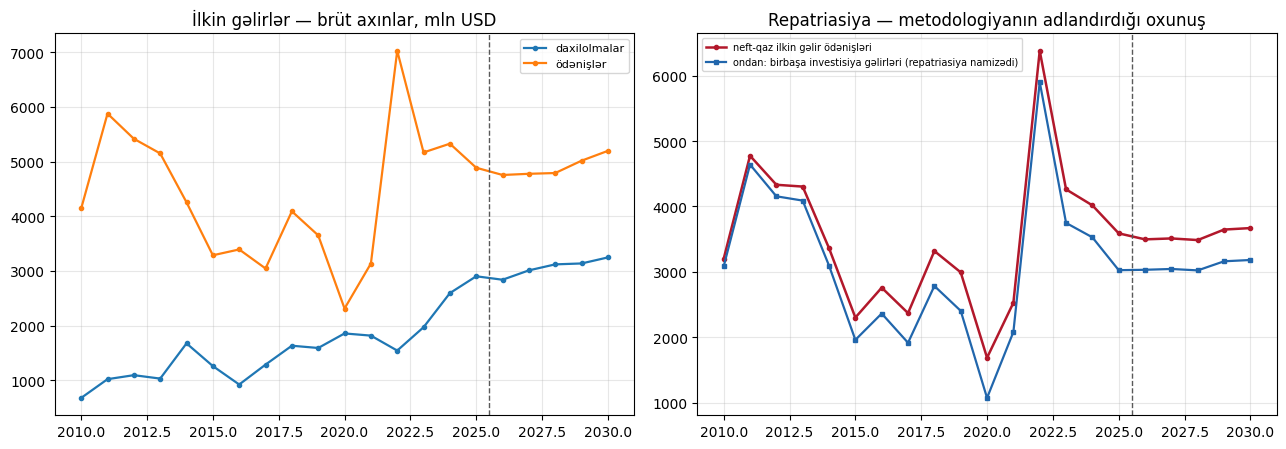

In [20]:
# ============ Brüt gəlir axınları: gəlir strukturunun cədvəli və qrafiki (FR11 struktur ekranı) ============
_inc_rows = []
for _blk, _lab in [("pi_credit_oil", "daxilolma — neft-qaz"),
                   ("pi_credit_nonoil", "daxilolma — qeyri-neft"),
                   ("pi_debit_oil", "ödəniş — neft-qaz"),
                   ("pi_debit_nonoil", "ödəniş — qeyri-neft")]:
    _full = pd.concat([G[_blk], GC[_blk]]).sort_index()
    _sh = {k: pd.concat([G[f"{_blk}_{k}"], GC[f"{_blk}_{k}"]]).sort_index() / _full * 100.0
           for k in ("di", "pf", "oth")}
    _inc_rows.append({"blok": _lab, "2010, mln USD": _full.loc[2010], "2025, mln USD": _full.loc[LA],
                      "2030, mln USD": _full.loc[FY[-1]],
                      "birbaşa inv. payı 2025, %": _sh["di"].loc[LA],
                      "portfel payı 2025, %": _sh["pf"].loc[LA],
                      "digər payı 2025, %": _sh["oth"].loc[LA]})
income_struct = pd.DataFrame(_inc_rows).set_index("blok").round(1)
print("İlkin gəlirlərin strukturu — blok və alət kəsiyi:")
print(income_struct.to_string())

_rep = pd.concat([G["pi_debit_oil_di"], GC["pi_debit_oil_di"]]).sort_index()
_rep92 = data_layer.actuals("fdi_repatriation")
print("\nRepatriasiyanın iki oxunuşu, mln USD (mənfi = ölkədən çıxış):")
print(pd.DataFrame({"metodologiya oxunuşu (ilkin gəlir ödənişi, sətir 70)": -_rep,
                    "maliyyə hesabı sətri 92 (İnvestisiyaların repatriasiyası)": _rep92
                    }).dropna(how="all").round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))
ax = axes[0]
for _c, _lab in [("pi_credit", "daxilolmalar"), ("pi_debit", "ödənişlər")]:
    _f = pd.concat([G[_c], GC[_c]]).sort_index()
    ax.plot(_f.index, _f.values, "-o", ms=3, lw=1.6, label=_lab)
ax.axvline(LA + 0.5, color="0.35", lw=1.0, ls="--")
ax.set_title("İlkin gəlirlər — brüt axınlar, mln USD"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1]
_f = pd.concat([G["pi_debit_oil"], GC["pi_debit_oil"]]).sort_index()
ax.plot(_f.index, _f.values, "-o", ms=3, lw=1.8, color="#b2182b",
        label="neft-qaz ilkin gəlir ödənişləri")
ax.plot(_rep.index, _rep.values, "-s", ms=3, lw=1.6, color="#2166ac",
        label="ondan: birbaşa investisiya gəlirləri (repatriasiya namizədi)")
ax.axvline(LA + 0.5, color="0.35", lw=1.0, ls="--")
ax.set_title("Repatriasiya — metodologiyanın adlandırdığı oxunuş")
ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


**Strukturun oxunuşu.** İlkin gəlir ödənişlərinin təxminən beşdə dördü neft-qaz sektoruna
düşür və onun içində birbaşa investisiya gəlirləri hakimdir — yəni ilkin gəlir balansının
kəsiri praktik olaraq **xarici investorların neft-qaz mənfəətinin ölkədən çıxışıdır**.
Daxilolmalar tərəfində mənzərə əksinədir: qeyri-neft bloku üstünlük təşkil edir və onun
əsas hissəsi portfel gəliridir — strateji valyuta ehtiyatının idarə edilməsindən gələn gəlir.

Üfüqdə iki qüvvə bir-birini əvəzləyir: neft-qaz ixracının dəyəri azaldıqca investor
ödənişləri də azalır, portfel gəliri isə ehtiyatın böyüməsi ilə artır — buna görə ilkin
gəlir balansının kəsiri 2026–2030-da daralır.


In [21]:
mb_pi = data_layer.ministry_baseline("primary_income")
mb_si = data_layer.ministry_baseline("secondary_income")
pd.DataFrame({
    "ilkin gəlirlər (bizim)": pi_central, "ilkin gəlirlər (şablon)": mb_pi,
    "təkrar gəlirlər (bizim)": si_central, "təkrar gəlirlər (şablon)": mb_si,
}).round(1)

,ilkin gəlirlər (bizim),ilkin gəlirlər (şablon),təkrar gəlirlər (bizim),təkrar gəlirlər (şablon)
2026,-1700.5,-757.3,932.2,726.2
2027,-1477.3,-500.7,923.3,831.2
2028,-1260.0,-461.6,921.3,911.0
2029,-1228.3,-439.7,920.8,982.6
2030,-1040.2,-580.4,920.7,1054.0


Şablon-nümunə ssenarisi ilkin gəlirlərin xalis çıxışını bizim mərkəzi yolumuzdan xeyli DAHA KİÇİK
(daha az mənfi) göstərir və üfüq boyu sürətlə daralır. Bu, iki fərqli fərziyyədən qaynaqlanır: FR7-nin
neft-qaz ixrac yolu Nazirliyin özününkündən yüksəkdir (FR07 Bölmə 7), ilkin gəlirlər isə birbaşa bu
yolla hərəkət edir. Təkrar gəlirlərdə fərq daha kiçikdir və hər iki yol da 2026-cı ildə 700–1 200 mln
dollar aralığında qalır.

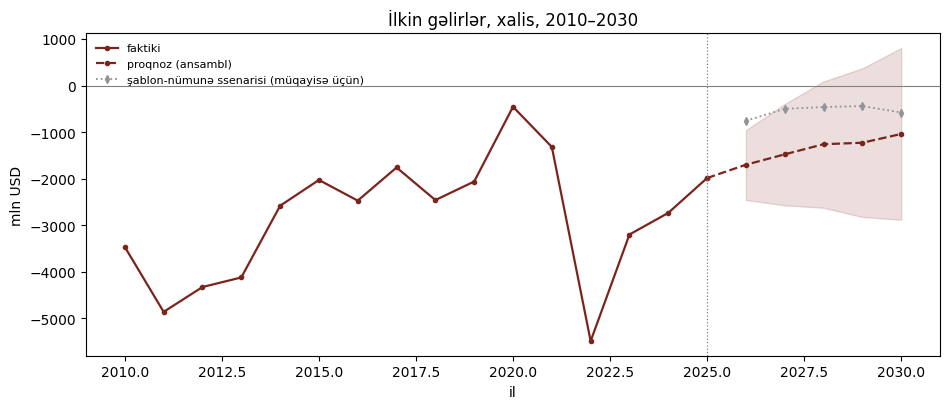

In [22]:
fig, ax = plt.subplots(figsize=(9.6, 4.2))
pi_full = pd.concat([PI, pi_central])
ax.plot(pi_full.loc[:LA].index, pi_full.loc[:LA], "-o", ms=3, lw=1.6, color="#7b241c", label="faktiki")
ax.plot(pi_full.loc[LA:].index, pi_full.loc[LA:], "--o", ms=3, lw=1.6, color="#7b241c", label="proqnoz (ansambl)")
ax.fill_between(pi_band.index, pi_band["lo80"], pi_band["hi80"], color="#7b241c", alpha=0.15)
ax.plot(mb_pi.index, mb_pi.values, ":d", ms=4, lw=1.3, color="#909497",
        label="şablon-nümunə ssenarisi (müqayisə üçün)")
ax.axhline(0, color="grey", lw=0.8)
ax.axvline(LA, color="grey", ls=":", lw=0.9)
ax.set_title("İlkin gəlirlər, xalis, 2010–2030")
ax.set_ylabel("mln USD"); ax.set_xlabel("il")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR11_ilkin_gelirler.png"), dpi=140)
plt.show()

## 8. Nəticələrin ixracı

Beş çıxış yazılır: proqnoz/faktiki sıralar (`outputs/forecast_long.csv`), tənlik kataloqu
(`outputs/equations_catalog.csv`), sınaq nəticələri (`outputs/validation_backtest.csv`), yeni
seriyaların lüğəti (`outputs/series_dictionary.csv`) və FR12-nin girişi olan iki fərziyyə yolu
(`data/assumptions.csv`). Sonda bütün eyniliklər yoxlanılır.

In [23]:
cat_names = data_layer.catalog().set_index("series_code")
NEW_SERIES = {
    "oil_trade_balance": ("Neft-qaz ticarət balansı", "Oil and gas trade balance", "mln USD"),
    "nonoil_trade_balance": ("Qeyri-neft ticarət balansı", "Non-oil trade balance", "mln USD"),
    "nonoil_coverage_ratio": ("Qeyri-neft örtmə əmsalı (ixrac/idxal)",
                             "Non-oil export/import coverage ratio", "%"),
}
for code_, wbcode, label, unit in CONC_ROWS:
    NEW_SERIES[code_] = (label, label, unit)

rows = []


def add(code_, name, unit, year, kind, source, value, band=None):
    rows.append({"fr": "FR11", "series_code": code_, "series_name_az": name, "unit": unit,
                 "year": int(year), "kind": kind, "source": source, "value": float(value),
                 "lo80": None if band is None else float(band["lo80"]),
                 "hi80": None if band is None else float(band["hi80"]),
                 "lo50": None if band is None else float(band["lo50"]),
                 "hi50": None if band is None else float(band["hi50"])})


# --- tərkib balansları və örtmə əmsalı --------------------------------------------------------
for code_, s_hist, s_fc, s_band, s_mb in [
    ("oil_trade_balance", oil_tb.loc[:LA], oil_tb.loc[FY], oil_tb_band, mtb_oil),
    ("nonoil_trade_balance", nonoil_tb.loc[:LA], nonoil_tb.loc[FY], nonoil_tb_band, mtb_nonoil),
    ("nonoil_coverage_ratio", nonoil_cov.loc[:LA], nonoil_cov.loc[FY], nonoil_cov_band, mcov),
]:
    name, _, unit = NEW_SERIES[code_]
    for y, v in s_hist.items():
        add(code_, name, unit, y, "actual", "ours", v)
    for y in FY:
        add(code_, name, unit, y, "forecast", "ours", s_fc.loc[y], s_band.loc[y])
    for y, v in s_mb.dropna().items():
        add(code_, name, unit, y, "forecast", "template_sample", v)

# --- ilkin/təkrar gəlirlər ---------------------------------------------------------------------
for y, v in PI.items():
    add("primary_income", str(cat_names.loc["primary_income", "name_az"]), "mln USD", y, "actual", "ours", v)
for y in FY:
    add("primary_income", str(cat_names.loc["primary_income", "name_az"]), "mln USD", y, "forecast",
        "ours", pi_central.loc[y], pi_band.loc[y])
for y, v in mb_pi.items():
    add("primary_income", str(cat_names.loc["primary_income", "name_az"]), "mln USD", y, "forecast",
        "template_sample", v)

for y, v in SI.items():
    add("secondary_income", str(cat_names.loc["secondary_income", "name_az"]), "mln USD", y, "actual", "ours", v)
for y in FY:
    add("secondary_income", str(cat_names.loc["secondary_income", "name_az"]), "mln USD", y, "forecast",
        "ours", si_central.loc[y], si_band.loc[y])
for y, v in mb_si.items():
    add("secondary_income", str(cat_names.loc["secondary_income", "name_az"]), "mln USD", y, "forecast",
        "template_sample", v)

# --- PUL BARATLARI (bu buraxılış) — faktiki tarixçə + proqnoz yolu -----------------------------------
# Proqnoz yolu nəşr olunan brüt axının SON ÜÇ İLLİK payı ilə qurulur; bu, baratın öz namizəd
# modeli ilə uzlaşan yeganə formadır (model elə həmin pay nisbətini işlədir) və axının
# ansamblından ayrı bir ikinci kanonik yol yaratmır.
REMIT_NAMES = {"si_credit": ("Fiziki şəxslərin pul baratları — daxilolmalar", "remit_credit"),
               "si_debit": ("Fərdlərin pul köçürmələri — ödənişlər", "remit_debit")}
REMIT_SHARE, REMIT_FC = {}, {}
for _leg, (_nm, _code) in REMIT_NAMES.items():
    _r = REMIT[_leg].dropna()
    _com = sorted(set(_r.index) & set(G[_leg].dropna().index))[-3:]
    _sh = float((_r.loc[_com] / G[_leg].loc[_com]).mean())
    REMIT_SHARE[_leg] = _sh
    REMIT_FC[_leg] = (GC[_leg] * _sh).rename(_code)
    for _y, _v in _r.items():
        add(_code, _nm, "mln USD", _y, "actual", "ours", _v)
    for _y in FY:
        add(_code, _nm, "mln USD", _y, "forecast", "ours", float(REMIT_FC[_leg].loc[_y]))
print("pul baratları nəşr olunur — son üç illik pay:",
      {k: round(v * 100, 1) for k, v in REMIT_SHARE.items()}, "%")
print(pd.DataFrame({"barat, daxilolma (proqnoz)": REMIT_FC["si_credit"].round(1),
                    "barat, ödəniş (proqnoz)": REMIT_FC["si_debit"].round(1)}).to_string())

# --- diversifikasiya sıraları (təsviri, SABİT proqnoz, bandsız) -------------------------------
for code_, _, _, _ in CONC_ROWS:
    name, _, unit = NEW_SERIES[code_]
    for y, v in CONC[code_].items():
        add(code_, name, unit, y, "actual", "ours", v)
    for y in FY:
        add(code_, name, unit, y, "forecast", "ours", CONC_FC[code_].loc[y])

# --- Brüt gəlir axınları: brüt ilkin/təkrar gəlir axınları, alət kəsiyi, fərq sıraları -------------------
_gnames = data_layer.catalog().set_index("series_code")
_GPUB = (["pi_credit", "pi_credit_oil", "pi_credit_nonoil", "pi_debit", "pi_debit_oil",
          "pi_debit_nonoil", "si_credit", "si_debit", "primary_income_oil",
          "primary_income_nonoil"] + GI_INSTR)
for _c in _GPUB:
    _nm = str(_gnames.loc[_c, "name_az"])
    NEW_SERIES.setdefault(_c, (_nm, str(_gnames.loc[_c, "name_en"]), "mln USD"))
    for _y, _v in G[_c].items():
        add(_c, _nm, "mln USD", _y, "actual", "ours", _v)
    for _y in FY:
        _bd = GBAND[_c].loc[_y] if _c in GBAND else None
        add(_c, _nm, "mln USD", _y, "forecast", "ours", float(GC.loc[_y, _c]), _bd)

# repatriasiya — MÜVƏQQƏTİ etiketli namizəd (tərif təsdiqi gözlənilir, Annex 2 sətir 14)
_REP_NM = ("Repatriasiya — MÜVƏQQƏTİ oxunuş: xarici investorların neft-qaz sektoru üzrə "
           "birbaşa investisiya gəlirləri (ilkin gəlir ödənişləri, sətir 70); tərif təsdiqi gözlənilir")
NEW_SERIES.setdefault("repatriasiya_namizedi", (_REP_NM, "Repatriation — provisional reading "
                      "(direct investment income within primary income payments, row 70)", "mln USD"))
for _y, _v in G["pi_debit_oil_di"].items():
    add("repatriasiya_namizedi", _REP_NM, "mln USD", _y, "actual", "ours", _v)
for _y in FY:
    add("repatriasiya_namizedi", _REP_NM, "mln USD", _y, "forecast", "ours",
        float(GC.loc[_y, "pi_debit_oil_di"]), GBAND["pi_debit_oil_di"].loc[_y])

for _c, _nm, _ser in [("pi_brut_ferq", "Brüt yığım ilə nəşr olunan xalis ilkin gəlir arasındakı fərq",
                       PI_GAP),
                      ("si_brut_ferq", "Brüt yığım ilə nəşr olunan xalis təkrar gəlir arasındakı fərq",
                       SI_GAP)]:
    NEW_SERIES.setdefault(_c, (_nm, "Gross build-up minus published net", "mln USD"))
    for _y, _v in _ser.items():
        add(_c, _nm, "mln USD", int(_y), ("actual" if _y <= LA else "forecast"), "ours", float(_v))

fl_new = pd.DataFrame(rows)
outputs.write_forecast_long(fl_new)
print(f"forecast_long.csv-ə yazıldı: {len(fl_new)} sətir, {fl_new['series_code'].nunique()} sıra")
fl_new.head(3)

pul baratları nəşr olunur — son üç illik pay: {'si_credit': 87.9, 'si_debit': 79.5} %
      barat, daxilolma (proqnoz)  barat, ödəniş (proqnoz)
2026                      1301.3                    551.1
2027                      1257.7                    551.1
2028                      1277.0                    551.1
2029                      1278.7                    551.1
2030                      1271.1                    551.1


forecast_long.csv-ə yazıldı: 858 sətir, 45 sıra


,fr,series_code,series_name_az,unit,year,kind,source,value,lo80,hi80,lo50,hi50
0,FR11,oil_trade_balance,Neft-qaz ticarət balansı,mln USD,2010,actual,ours,24269.892,NaN,NaN,NaN,NaN
1,FR11,oil_trade_balance,Neft-qaz ticarət balansı,mln USD,2011,actual,ours,31736.280,NaN,NaN,NaN,NaN
2,FR11,oil_trade_balance,Neft-qaz ticarət balansı,mln USD,2012,actual,ours,29657.659,NaN,NaN,NaN,NaN


In [24]:
WB = "Statistik data dinamika 05.06.2026 +.xlsx"
SH = "Tədiyyə Balansı"
cat_rows = pd.DataFrame([
    res_pi_full.catalog_row(
        eq_name="FR11_ilkin_gelirler_struktur",
        description="STRUKTUR: Δ ilkin gəlirlər ~ Δ neft-qaz mal ixracı (dummisiz)",
        lhs="Δ primary_income", series_code="primary_income", fr="FR11", workbook=WB, sheet=SH),
    res_pi_d15_full.catalog_row(
        eq_name="FR11_ilkin_gelirler_struktur_d15",
        description=("STRUKTUR: Δ ilkin gəlirlər ~ Δ neft-qaz mal ixracı + 2015-2016 devalvasiya "
                     "dummisi — geriyə doğru sınaqda daha böyük ansambl çəkisi alıb"),
        lhs="Δ primary_income", series_code="primary_income", fr="FR11", workbook=WB, sheet=SH),
])
# --- Brüt gəlir axınları: brüt axınların qazanan və sınanmış-uduzan spesifikasiyaları (D4) ---------------
_G_RATIONALE = {
    "pi_credit_oil": "neft-qaz sektorunun xaricdən gəlir daxilolmaları (kiçik maddə)",
    "pi_credit_nonoil": "ARDNF + MB portfelinin investisiya gəliri ← əvvəlki ilin ehtiyat stoku",
    "pi_debit_oil": "xarici investorların neft-qaz gəliri ← neft-qaz mal ixracının dəyəri",
    "pi_debit_nonoil": "qeyri-neft sektorunda xarici investor gəliri ← xarici investisiya axını",
    "si_credit": "təkrar gəlir daxilolmaları (baratlar daxil; barat sırası artıq AYRICA nəşr olunur — `remit_credit`)",
    "si_debit": "təkrar gəlir ödənişləri",
    "pi_debit_oil_di": "REPATRİASİYA NAMİZƏDİ (metodologiya oxunuşu) ← neft-qaz ixracının dəyəri",
}
_g_cat = []
for _c in GROSS:
    _b = GBT[_c]
    for _m in sorted(_b.rmse):
        if _m == "RW" or _b.rmse[_m] is None:
            continue
        _sk = None if not _b.rw_rmse else (1 - _b.rmse[_m] / _b.rw_rmse) * 100
        _kept = _m in _b.weights
        _g_cat.append({
            "workbook": WB, "sheet": SH, "eq_name": f"FR11_{_c}_{_m.lower()}",
            "description": (("STRUKTUR" if _kept else "SINANMIŞ (mərkəzi yola buraxılmayıb)")
                            + f": {_G_RATIONALE[_c]}; model {_m}, RW-yə nisbətdə bacarıq "
                            + ("n/a" if _sk is None else f"{_sk:+.1f} %")
                            + (f", ansambl çəkisi {_b.weights[_m]:.2f}" if _kept else "")),
            "lhs": _c, "rhs": _G_RATIONALE[_c], "series_code": _c, "fr": "FR11",
            "sample_start": 2010, "sample_end": int(LA), "adj_r2": None,
            "se_regression": round(_b.rmse[_m], 3)})
# `adf_r2` bütün brüt sətirlərdə None olduğu üçün çərçivə obyekt tipində qalır və pandas
# konkatenasiyada FutureWarning verir; sütun açıq şəkildə float-a çevrilir (None → NaN).
_g_df = pd.DataFrame(_g_cat)
_g_df["adj_r2"] = pd.to_numeric(_g_df["adj_r2"], errors="coerce").astype(float)
cat_rows = pd.concat([cat_rows, _g_df], ignore_index=True)
outputs.write_equations_catalog(cat_rows)
print(f"equations_catalog.csv-ə yazıldı: {len(cat_rows)} sətir")
cat_rows

equations_catalog.csv-ə yazıldı: 30 sətir


,workbook,sheet,eq_name,description,lhs,rhs,series_code,fr,sample_start,sample_end,adj_r2,se_regression
0,Statistik data dinamika 05.06.2026 +.xlsx,Tədiyyə Balansı,FR11_ilkin_gelirler_struktur,STRUKTUR: Δ ilkin gəlirlər ~ Δ neft-qaz mal ix...,Δ primary_income,dxo,primary_income,FR11,2011,2025,0.7950,693.5664
1,Statistik data dinamika 05.06.2026 +.xlsx,Tədiyyə Balansı,FR11_ilkin_gelirler_struktur_d15,STRUKTUR: Δ ilkin gəlirlər ~ Δ neft-qaz mal ix...,Δ primary_income,dxo + d15,primary_income,FR11,2011,2025,0.9088,462.6179
2,Statistik data dinamika 05.06.2026 +.xlsx,Tədiyyə Balansı,FR11_pi_credit_oil_orta3,STRUKTUR: neft-qaz sektorunun xaricdən gəlir d...,pi_credit_oil,neft-qaz sektorunun xaricdən gəlir daxilolmala...,pi_credit_oil,FR11,2010,2025,NaN,279.1220
3,Statistik data dinamika 05.06.2026 +.xlsx,Tədiyyə Balansı,FR11_pi_credit_oil_qeyri̇neft,SINANMIŞ (mərkəzi yola buraxılmayıb): neft-qaz...,pi_credit_oil,neft-qaz sektorunun xaricdən gəlir daxilolmala...,pi_credit_oil,FR11,2010,2025,NaN,343.3890
4,Statistik data dinamika 05.06.2026 +.xlsx,Tədiyyə Balansı,FR11_pi_credit_oil_sürüşmə,SINANMIŞ (mərkəzi yola buraxılmayıb): neft-qaz...,pi_credit_oil,neft-qaz sektorunun xaricdən gəlir daxilolmala...,pi_credit_oil,FR11,2010,2025,NaN,333.7000
5,Statistik data dinamika 05.06.2026 +.xlsx,Tədiyyə Balansı,FR11_pi_credit_nonoil_ehti̇yat_səvi̇yyəsi̇,STRUKTUR: ARDNF + MB portfelinin investisiya g...,pi_credit_nonoil,ARDNF + MB portfelinin investisiya gəliri ← əv...,pi_credit_nonoil,FR11,2010,2025,NaN,258.0980
6,Statistik data dinamika 05.06.2026 +.xlsx,Tədiyyə Balansı,FR11_pi_credit_nonoil_orta3,SINANMIŞ (mərkəzi yola buraxılmayıb): ARDNF + ...,pi_credit_nonoil,ARDNF + MB portfelinin investisiya gəliri ← əv...,pi_credit_nonoil,FR11,2010,2025,NaN,398.5700
7,Statistik data dinamika 05.06.2026 +.xlsx,Tədiyyə Balansı,FR11_pi_credit_nonoil_sürüşmə,STRUKTUR: ARDNF + MB portfelinin investisiya g...,pi_credit_nonoil,ARDNF + MB portfelinin investisiya gəliri ← əv...,pi_credit_nonoil,FR11,2010,2025,NaN,303.5460
8,Statistik data dinamika 05.06.2026 +.xlsx,Tədiyyə Balansı,FR11_pi_debit_oil_neft_i̇xrac,STRUKTUR: xarici investorların neft-qaz gəliri...,pi_debit_oil,xarici investorların neft-qaz gəliri ← neft-qa...,pi_debit_oil,FR11,2010,2025,NaN,727.5980
9,Statistik data dinamika 05.06.2026 +.xlsx,Tədiyyə Balansı,FR11_pi_debit_oil_orta3,STRUKTUR: xarici investorların neft-qaz gəliri...,pi_debit_oil,xarici investorların neft-qaz gəliri ← neft-qa...,pi_debit_oil,FR11,2010,2025,NaN,1597.3390


In [25]:
bt_rows = pd.concat([bt_pi.table, bt_si.table, bt_pi_brut.table, bt_si_brut.table]
                    + [GBT[c].table for c in GROSS], ignore_index=True)
outputs.write_backtest(bt_rows)
print(f"validation_backtest.csv-ə yazıldı: {len(bt_rows)} sətir")

dict_rows = pd.DataFrame([
    {"series_code": c, "name_az": NEW_SERIES[c][0], "name_en": NEW_SERIES[c][1],
     "unit": NEW_SERIES[c][2], "fr": "FR11",
     "statutory_sheet_ref": ("8 vərəq, 2.4.1.13.-14." if c in
                            ("oil_trade_balance", "nonoil_trade_balance", "nonoil_coverage_ratio")
                            else "Ticarət (əsas iş kitabı)")}
    for c in NEW_SERIES
])
_REMIT_DICT = pd.DataFrame([
    {"series_code": "remit_credit", "name_az": "Fiziki şəxslərin pul baratları — daxilolmalar",
     "name_en": "Personal remittances — credit", "unit": "mln USD", "fr": "FR11",
     "price_basis": "cari",
     "statutory_sheet_ref": ("MOE BOP `Income account` sətir 74 (1996–2024, YALNIZ faktiki "
                             "sütunlar) + AMB NSDP `BOP Analytical` sətir 48 (2025); "
                             "`si_credit` brüt axınının BARAT namizəd modelinin bazası")},
    {"series_code": "remit_debit", "name_az": "Fərdlərin pul köçürmələri — ödənişlər",
     "name_en": "Personal remittances — debit", "unit": "mln USD", "fr": "FR11",
     "price_basis": "cari",
     "statutory_sheet_ref": ("MOE BOP `Income account` sətir 83 (1996–2024) + AMB NSDP "
                             "(2025, eyniliklə: daxilolma − xalis); `si_debit` axınının "
                             "BARAT_SÜRÜŞMƏ modelinin bazası — yarışın QALİBİ")},
])
outputs.write_series_dictionary(_REMIT_DICT)
outputs.write_series_dictionary(dict_rows)
print(f"series_dictionary.csv-ə yazıldı: {len(dict_rows)} yeni sıra")

validation_backtest.csv-ə yazıldı: 347 sətir
series_dictionary.csv-ə yazıldı: 41 yeni sıra


### Dinamiklik göstəricisi və dinamika formaları

**Dinamiklik göstəricisi** — $\sigma(\text{proqnoz}_{2026-2030})/\sigma(\text{faktiki}_{2013-2025})$,
hər ikisi populyasiya standart kənarlaşmasıdır. `validation_backtest.csv`-ə `model = "DINAMIKLIK"`
sətirləri ilə yazılır: `actual` = σ(faktiki), `forecast` = σ(proqnoz), `rmse_h` = göstəricinin özü,
`rw_rmse_h` = istinad dəyəri 1,0. Şərti orta proqnoz tərifinə görə faktikidən az dəyişkəndir, ona
görə 1-dən kiçik dəyər qüsur deyil; sıfıra yaxın dəyər isə proqnozun praktik olaraq sabit olduğunu
bildirir.

**Dinamika formaları** — hər davranış tənliyi statik, gecikmiş asılı dəyişənli və ECM formalarında
qurulur; qərarı genişlənən pəncərəli, bir addımlıq sınaq verir (D3/D4). Uduzan forma
silinmir: `<kod>_dinamika` adı ilə eyni fayla yazılır.


In [26]:
# DİNAMİKLİK GÖSTƏRİCİSİ — ilkin və təkrar gəlirlər (səviyyə sıraları, mln USD).
_dyn11 = []
for _code, _lab, _fc, _just, _cls in [
        ("primary_income", "İlkin gəlirlər (xalis)", pi_central,
         "yol neft-qaz ixracının dəyəri ilə şərtlənir; onun öz yolu hamardır", "ekzogen"),
        # Təkrar gəlirlər: heç bir struktur sürücü tapılmadı, mərkəzi yolu ETALON (profil
        # ansamblı) daşıyır — uduzan yarışın ünvanı qeyddə göstərilir.
        ("secondary_income", "Təkrar gəlirlər (xalis)", si_central,
         "sıra üçün struktur sürücü tapılmayıb; mərkəzi yol profil sınağının nəticəsidir; "
         "yarış `validation_backtest.csv`-də `secondary_income` sətirlərindədir "
         "(ORTA / RW namizədləri)", "etalon")]:
    try:
        _dyn11.append(ek.sigma_ratio(pd.Series(_fc).reindex(FY), data_layer.actuals(_code),
                                     series_code=_code, label_az=_lab, justification=_just,
                                     dyn_class=_cls))
    except Exception as _e:
        print(f"  DİQQƏT: {_code} — dinamiklik göstəricisi hesablanmadı ({_e})")
if _dyn11:
    outputs.write_backtest(ek.dynamics_rows(_dyn11))
    ek.assert_dynamics_band(_dyn11, strict=False)
    outputs.publish_dynamics_notes(_dyn11)
    display(pd.DataFrame([{"sıra": r.series_code, "σ(faktiki)": round(r.sd_actual, 3),
                           "σ(proqnoz)": round(r.sd_forecast, 3),
                           "dinamiklik": round(r.ratio, 3)} for r in _dyn11]))


D2: 2 sıra üçün dinamiklik əsaslandırması seriya lüğətinə yazıldı

,sıra,σ(faktiki),σ(proqnoz),dinamiklik
0,primary_income,1205.734,226.966,0.188
1,secondary_income,721.952,4.372,0.006


In [27]:
assum_rows = pd.DataFrame(
    [{"assumption_key": "primary_income", "year": y, "value": float(pi_central.loc[y]),
      "unit": "mln USD",
      "note": (f"FR11 struktur tənliyi (Δ ilkin gəlirlər ~ Δ neft-qaz ixracı, dummisiz və "
               f"2015-2016 dummili variantların ansamblı, çəkilər {W_pi}); FR12-nin girişi")}
     for y in FY]
    + [{"assumption_key": "secondary_income", "year": y, "value": float(si_central.loc[y]),
        "unit": "mln USD",
        "note": (f"FR11 profil yolu: {si_note}; v2-nin sabit kalibrləməsi "
                 f"{si_mean5:.1f} mln USD idi, bir addımlıq sınaqda RW-ni üstələyir "
                 f"(bacarıq {bt_si.skill * 100:.0f} %); FR12-nin girişi")}
       for y in FY]
)
outputs.write_assumptions(assum_rows)
print(f"assumptions.csv-ə yazıldı: {len(assum_rows)} sətir (primary_income, secondary_income)")
assum_rows

assumptions.csv-ə yazıldı: 10 sətir (primary_income, secondary_income)


,assumption_key,year,value,unit,note
0,primary_income,2026,-1700.529237,mln USD,FR11 struktur tənliyi (Δ ilkin gəlirlər ~ Δ ne...
1,primary_income,2027,-1477.299221,mln USD,FR11 struktur tənliyi (Δ ilkin gəlirlər ~ Δ ne...
2,primary_income,2028,-1259.971435,mln USD,FR11 struktur tənliyi (Δ ilkin gəlirlər ~ Δ ne...
3,primary_income,2029,-1228.328306,mln USD,FR11 struktur tənliyi (Δ ilkin gəlirlər ~ Δ ne...
4,primary_income,2030,-1040.220141,mln USD,FR11 struktur tənliyi (Δ ilkin gəlirlər ~ Δ ne...
5,secondary_income,2026,932.218966,mln USD,"FR11 profil yolu: profil: ORTA5 0.53, AR1 0.47..."
6,secondary_income,2027,923.333643,mln USD,"FR11 profil yolu: profil: ORTA5 0.53, AR1 0.47..."
7,secondary_income,2028,921.297544,mln USD,"FR11 profil yolu: profil: ORTA5 0.53, AR1 0.47..."
8,secondary_income,2029,920.830965,mln USD,"FR11 profil yolu: profil: ORTA5 0.53, AR1 0.47..."
9,secondary_income,2030,920.724047,mln USD,"FR11 profil yolu: profil: ORTA5 0.53, AR1 0.47..."


In [28]:
v = validate.Verifier("FR11 — Ticarət-tədiyə strukturu")

# 1. məcmu ticarət balansı = neft-qaz + qeyri-neft, HƏR il (2010-2030)
v.identity("ticarət balansı = neft-qaz + qeyri-neft (2010-2030)", TB_full, oil_tb + nonoil_tb, tol=1e-6)

# 2. cari hesab eyniliyi, faktiki illər (2010-2025) — müstəqil komponentlərdən
v.identity("cari hesab = ticarət + xidmətlər + ilkin + təkrar gəlirlər (2010-2025)",
           CA, TB_full.loc[:LA] + SB + PI + SI, tol=1e-6)

# 3. ixrac edilən faktiki sıralar FR7-nin öz mənbəyi ilə eynidir (Bölmə 2-də əvvəlcədən yoxlanılıb,
#    burada təkrar təsdiqlənir)
for c in TRADE_CODES:
    v.identity(f"faktiki hissə FR7 ilə eynidir: {c}", HIST[c], data_layer.actuals(c), tol=1e-9)

# 4. ansambl çəkilərinin cəmi = 1
v.close("ansambl çəkilərinin cəmi = 1: ilkin gəlirlər", sum(bt_pi.weights.values()), 1.0, tol=1e-12)
v.close("ansambl çəkilərinin cəmi = 1: təkrar gəlirlər", sum(bt_si.weights.values()), 1.0, tol=1e-12)

# 5. yelpik zolağı mərkəzi yolu əhatə edir və üfüq boyu genişlənir
for name, central_, band_ in [("ilkin gəlirlər", pi_central, pi_band),
                              ("təkrar gəlirlər", si_central, si_band),
                              ("neft-qaz ticarət balansı", oil_tb.loc[FY], oil_tb_band),
                              ("qeyri-neft ticarət balansı", nonoil_tb.loc[FY], nonoil_tb_band),
                              ("qeyri-neft örtmə əmsalı", nonoil_cov.loc[FY], nonoil_cov_band)]:
    v.ok(f"yelpik zolağı mərkəzi yolu əhatə edir: {name}",
         bool((band_["lo80"] <= central_).all() and (band_["hi80"] >= central_).all()))
    v.ok(f"yelpik zolağı üfüq boyu genişlənir: {name}",
         bool((band_["hi80"] - band_["lo80"]).diff().dropna().gt(-1e-9).all()))

# 6. gələcəyə baxış yoxdur — qiymətləndirmə nümunələri VƏ sınaq pəncərələri
for nm, res_ in [("ilkin gəlirlər (dummisiz)", res_pi_full), ("ilkin gəlirlər (dummili)", res_pi_d15_full)]:
    v.ok(f"gələcəyə baxış yoxdur: {nm}", res_.sample[1] <= LA,
         f"nümunə {res_.sample[0]}–{res_.sample[1]}, n = {res_.n}")
# Nümunə indeksi tərifinə görə ≤ LA-dır; sınaq PƏNCƏRƏLƏRİ isə ayrıca yoxlanılmalıdır.
v.no_lookahead("sınaq pəncərəsi: ilkin gəlirlər", pd.Index(bt_pi.common_years))
v.no_lookahead("sınaq pəncərəsi: təkrar gəlirlər", pd.Index(bt_si.common_years))
for _c in GROSS:
    v.no_lookahead(f"sınaq pəncərəsi: {_c}", pd.Index(GBT[_c].common_years))

# 7. müstəqil yenidən hesablama: 2026-cı il neft-qaz ticarət balansı, xam fayldan yenidən oxunaraq
def _yenidən_hesabla_oil_tb_2026():
    raw = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))
    raw = raw[(raw["fr"] == "FR7") & (raw["source"] == "ours") & (raw["kind"] == "forecast")
             & (raw["year"] == 2026)].set_index("series_code")["value"]
    return float(raw["exp_goods_oil"] - raw["imp_goods_oil"])


v.recompute("2026 neft-qaz ticarət balansı (müstəqil yenidən hesablama)",
            float(oil_tb.loc[2026]), _yenidən_hesabla_oil_tb_2026, tol=1e-6)

# 8. 2025 cari hesabın müstəqil yenidən hesablanması (Bölmə 2.1-in ədədlərinin təkrar yoxlanışı)
v.recompute("2025 cari hesab (müstəqil yenidən hesablama)", ca_2025,
            lambda: tb_2025 + sb_2025 + pi_2025 + si_2025, tol=1e-6)

# --- Brüt gəlir axınlarının eynilikləri: brüt qat, 2010–2030-un HƏR ilində --------------------------------------
_pc = pd.concat([G["pi_credit"], GC["pi_credit"]]).sort_index()
_pd_ = pd.concat([G["pi_debit"], GC["pi_debit"]]).sort_index()
_pco = pd.concat([G["pi_credit_oil"], GC["pi_credit_oil"]]).sort_index()
_pcn = pd.concat([G["pi_credit_nonoil"], GC["pi_credit_nonoil"]]).sort_index()
_pdo = pd.concat([G["pi_debit_oil"], GC["pi_debit_oil"]]).sort_index()
_pdn = pd.concat([G["pi_debit_nonoil"], GC["pi_debit_nonoil"]]).sort_index()
v.identity("brüt: daxilolmalar = neft-qaz + qeyri-neft (2010-2030)", _pc, _pco + _pcn, tol=1e-6)
v.identity("brüt: ödənişlər = neft-qaz + qeyri-neft (2010-2030)", _pd_, _pdo + _pdn, tol=1e-6)
for _blk, _s in [("pi_credit_oil", _pco), ("pi_credit_nonoil", _pcn),
                 ("pi_debit_oil", _pdo), ("pi_debit_nonoil", _pdn)]:
    _parts = sum(pd.concat([G[f"{_blk}_{k}"], GC[f"{_blk}_{k}"]]).sort_index()
                 for k in ("di", "pf", "oth"))
    v.identity(f"alət kəsiyi cəmi = blok: {_blk} (2010-2030)", _s, _parts, tol=1e-6)
v.identity("fərq sırası = brüt yığım − nəşr olunan xalis (ilkin gəlirlər)", PI_GAP,
           (PI_BRUT - PI_FULL).reindex(PI_GAP.index), tol=1e-9)
v.identity("fərq sırası = brüt yığım − nəşr olunan xalis (təkrar gəlirlər)", SI_GAP,
           (SI_BRUT - SI_FULL).reindex(SI_GAP.index), tol=1e-9)
v.ok("faktiki illərdə brüt yığım nəşr olunan xalis göstərici ilə DƏQİQ üst-üstə düşür",
     bool(PI_GAP.loc[:LA].abs().max() < 1e-6 and SI_GAP.loc[:LA].abs().max() < 1e-6),
     f"maksimal |fərq| {max(float(PI_GAP.loc[:LA].abs().max()), float(SI_GAP.loc[:LA].abs().max())):.2e}")
for _c in GROSS:
    v.close(f"ansambl çəkilərinin cəmi = 1: {_c}", sum(GBT[_c].weights.values()), 1.0, tol=1e-12)
v.ok("repatriasiya namizədi MÜVƏQQƏTİ etiketlə nəşr olunur (tərif təsdiqi gözlənilir)",
     "MÜVƏQQƏTİ" in _REP_NM)

# --- NƏŞR OLUNAN SƏTİRLƏRİN GERİ OXUNMASI ----------------------------------------------------
# Bu dəftər eyni iki kəmiyyəti HƏM `assumptions.csv`-ə, HƏM də `forecast_long.csv`-ə yazır və
# FR12 sonuncunu oxuyur. İki nüsxə arasında fərq yaransa, paketdə bir kəmiyyət üçün iki yol
# olardı — ona görə hər ikisi diskdən geri oxunub hesablanmış yolla tutuşdurulur.
_asm11 = outputs.read_assumptions()
_fl11_back = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))
_fl11_back = _fl11_back[(_fl11_back["fr"] == "FR11") & (_fl11_back["source"] == "ours")
                        & (_fl11_back["kind"] == "forecast")]
for _k, _central, _band in (("primary_income", pi_central, pi_band),
                            ("secondary_income", si_central, si_band)):
    v.ok(f"assumptions.csv-də {_k} açarı var", _k in _asm11)
    v.identity(f"fərziyyə: {_k} = mərkəzi yol (hər il)",
               _asm11[_k].reindex(FY), _central.reindex(FY), tol=1e-9)
    _row = _fl11_back[_fl11_back["series_code"] == _k].set_index("year")
    v.identity(f"forecast_long: {_k} = mərkəzi yol (hər il)",
               _row["value"], _central.reindex(FY), tol=1e-9)
    v.identity(f"forecast_long: {_k} lo80 = hesablanmış zolaq (hər il)",
               _row["lo80"], _band["lo80"].reindex(FY), tol=1e-9)
    v.identity(f"forecast_long: {_k} hi80 = hesablanmış zolaq (hər il)",
               _row["hi80"], _band["hi80"].reindex(FY), tol=1e-9)

# D1 — hər açarın hər ili üçün yalnız bir sətir
_raw11 = pd.read_csv(config.ASSUMPTIONS)
_dup11 = _raw11.duplicated(["assumption_key", "year"])
v.ok("assumptions.csv-də təkrarlanan (açar, il) sətri yoxdur (D1)",
     bool(_dup11.sum() == 0), f"təkrar sətir sayı: {int(_dup11.sum())}")

v.assert_all()

  YOXLAMA: FR11 — Ticarət-tədiyə strukturu
  [PASS] eynilik: ticarət balansı = neft-qaz + qeyri-neft (2010-2030)
         21 il, maksimal fərq 3.638e-12
  [PASS] eynilik: cari hesab = ticarət + xidmətlər + ilkin + təkrar gəlirlər (2010-2025)
         16 il, maksimal fərq 3.638e-12
  [PASS] eynilik: faktiki hissə FR7 ilə eynidir: exp_goods_oil
         16 il, maksimal fərq 0.000e+00
  [PASS] eynilik: faktiki hissə FR7 ilə eynidir: imp_goods_oil
         16 il, maksimal fərq 0.000e+00
  [PASS] eynilik: faktiki hissə FR7 ilə eynidir: exp_goods_nonoil
         16 il, maksimal fərq 0.000e+00
  [PASS] eynilik: faktiki hissə FR7 ilə eynidir: imp_goods_nonoil
         16 il, maksimal fərq 0.000e+00
  [PASS] ansambl çəkilərinin cəmi = 1: ilkin gəlirlər
         maksimal fərq 0.000e+00 ≤ 1.0e-12
  [PASS] ansambl çəkilərinin cəmi = 1: təkrar gəlirlər
         maksimal fərq 0.000e+00 ≤ 1.0e-12
  [PASS] yelpik zolağı mərkəzi yolu əhatə edir: ilkin gəlirlər
  [PASS] yelpik zolağı üfüq boyu genişləni

## 9. Məhdudiyyətlər

**Brüt qatın açıq məhdudiyyətləri.** (i) **Baratlar (remittances) — BOŞLUQ BAĞLANDI (bu buraxılış).**
Əvvəlki buraxılışda sıra nə əsas iş kitabında, nə statutar şablonda, nə də registrdə tapılmırdı və
Annex 2-nin 15-ci sətrində Nazirlikdən istənilirdi. Açıq mənbə sweep-i onu iki müstəqil yerdə tapdı —
MOE BOP `Income account` (sətir 74 / 83, **1996–2024**, yalnız faktiki sütunlar) və AMB NSDP
`BOP Analytical` (**2013–2025**, 2025 üçün yeganə faktiki mənbə) — iki mənbə üst-üstə düşən on iki
ildə ≤ 1,1 mln USD fərqlə eynidir. Sıra artıq `remit_credit` / `remit_debit` kodları ilə **nəşr olunur**
və `si_credit` / `si_debit` axınları üçün namizəd model verir; `si_debit`-də bu model yarışın
**qalibidir** (əvvəlki buraxılışda həmin axın üçün heç bir model təsadüfi gəzişməni üstələmirdi).
Qalan yeganə sorğu bənd — sıranın metodoloji davamlılığının təsdiqi.
Baratın proqnoz yolu ayrıca kanonik yol DEYİL: o, nəşr olunan brüt axının son üç illik payı ilə
qurulur, ona görə iki sıra arasında ikinci, uzlaşmayan oxunuş yaranmır.
(ii) **Repatriasiyanın tərifi təsdiq gözləyir**: metodologiya sənədinin adlandırdığı oxunuş
(`pi_debit_oil_di`, vərəqin 70-ci sətri) müvəqqəti etiketlə nəşr olunur, maliyyə hesabındakı
ikinci namizəd (`fdi_repatriation`, sətir 92) isə yanaşı göstərilir — seçim Nazirliyə aiddir
(Annex 2, sətir 14; görüş gündəliyi, bənd 4). (iii) **Alət payları modelləşdirilmir**: birbaşa
investisiya / portfel / digər bölgüsü son üç ilin orta payı ilə sabit saxlanılır, çünki alt
sətirlərin özləri üçün ayrıca iqtisadi sürücü yoxdur; payların cəmi eynilikdə vahidə bərabərdir.

**Ehtiyat stokunun yolu sabitdir.** Qeyri-neft ilkin gəlir daxilolmalarının sürücüsü —
strateji valyuta ehtiyatının stoku — öz profil sınağında SABİT yol seçib (heç bir dinamik
namizəd sabit yolu üstələməyib). Ona görə portfel gəlirinin üfüq boyu artımı stokdan deyil,
ansamblın digər üzvlərindən gəlir. Ehtiyatın AXINI isə FR12-nin bağlanışından çıxır və orada
bu stok yolu ilə açıq şəkildə tutuşdurulur; iki kəmiyyət arasındakı fərq (yenidənqiymətləndirmə)
FR12-nin ikinci çarpaz yoxlamasında ölçülür.


**Şərti proqnoz.** Tərkib balansları, örtmə əmsalı və ilkin gəlirlər FR7-nin (dolayısı ilə FR05-in
neft qiyməti və FR01-in absorbsiya yollarının) proqnozlarından asılıdır. Bu dəftərin özü yeni
qeyri-müəyyənlik mənbəyi əlavə etmir; onun zolaqları yalnız öz tənliklərinin (ilkin gəlirlər) və ya
komponent zolaqlarının (balanslar) toplanmasından qaynaqlanır, yuxarı axının qeyri-müəyyənliyini
tam əhatə etmir.

**DATA-GAP: diversifikasiya sıralarının qısa nümunəsi.** Ticarət vərəqinin diversifikasiya bloku
2021-ci ildən (bəzi sətirlər 2018-dən) başlayır. n = 5–8 müşahidə etibarlı reqressiya üçün kifayət
deyil; 2026–2030 proqnozu 2025-ci il dəyərində sabit saxlanılır və heç bir yelpik zolağı verilmir —
bu, ekonometrik proqnoz deyil, sadə davamlılıq fərziyyəsidir.

**İlkin gəlirlər tənliyinin iqtisadi mexanizmi tam modelləşdirilmir.** 2015–2016 dummisinin
statistik əhəmiyyəti aydındır, lakin onun arxasındakı mexanizm (PSA-ların xərc-bərpası və
mənfəət-neft düsturlarının qiymət çöküşünə qeyri-xətti reaksiyası) bu dəftərdə ayrıca
modelləşdirilmir, yalnız fərziyyə kimi qeyd olunur. Struktur tənlik ona görə **reduksiya edilmiş
forma** (reduced form) xarakterlidir, PSA-ların özünün modelidir demək olmaz.

**Təkrar gəlirlərin yolu profil yarışının nəticəsidir, struktur tənlik deyil.** Sıra kiçik, işarəsi
dəyişkən (2012-ci ildə mənfi, 2022-ci ildə fövqəladə yüksək) və heç bir makro sürücüyə əhəmiyyətli
dərəcədə bağlı deyil. Ona görə davranış tənliyi qurulmur: yol çoxüfüqlü sınaqda seçilən profil
namizədlərinin (bu buraxılışda ORTA5 0,53 + AR(1) 0,47) çəkili birləşməsidir və praktik olaraq düzdür
(932 → 921 mln USD). Bu, mərkəzi tendensiyanın ölçülmüş davamıdır — iqtisadi mexanizmin modeli deyil;
zolağın genişliyi (Bölmə 7, h = 1 üçün ±915, h = 5 üçün ±1 418 mln USD) bu qeyri-müəyyənliyi əks
etdirir.

**Balansların yelpik zolağı konservativdir və uzun üfüqdə həddindən artıq genişdir.** FR07-nin
konvensiyası ilə komponent zolaqları ən pis halda — xətaların bir-birini əks istiqamətdə
gücləndirdiyi fərziyyə ilə — birləşdirilir (yarım-enlərin toplanması), halbuki praktikada ixrac və
idxal xətaları eyni sürücülərdən (neft qiyməti, daxili absorbsiya) qidalanır və qismən üst-üstə
düşür. Nəticə: örtmə əmsalının 80 % zolağı 2030-cu ildə 1,8–42,5 % aralığına açılır, yəni aşağı
sərhəd praktik məlumat daşımır. Zolaq bu halda **yuxarı hədd** kimi oxunmalıdır; planlaşdırma üçün
50 % zolaq (2030: 11,8–32,5 %) daha işlək çərçivədir.

**Sınaq nəticələri şərtidir.** Həm ilkin gəlirlər tənliyinin, həm də 7.4-ün brüt axın modellərinin
sınağında cari ilin sürücü dəyəri (neft-qaz ixracının dəyəri, xarici investisiya, qeyri-neft artımı)
FAKTİKİ dəyəri ilə verilir — bu, FR07-nin konvensiyasıdır və müqayisəni ədalətli saxlayır, lakin
ölçülən bacarıq real vaxt dəqiqliyinin **yuxarı sərhədidir**. Proqnoz üfüqündə həmin sürücülər
yuxarı axının öz proqnozlarıdır; onların xətası bu dəftərin zolaqlarına daxil edilmir (bax
«Şərti proqnoz» bəndi).